In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


# Separate populations

In [395]:
# Define the omega values to iterate over
lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
velocities = [5.0, 20.0, 100.0]
n_files = length(lambdas)
steps = 60000

for (idx_v, v) in enumerate(velocities)
    rows = 4
    cols = 4
    fig3 = Figure(size=(900 * cols, 600 * rows))

    for (idx, lambda) in enumerate(lambdas)
    
        filename = @sprintf("fsb_%s_lambda_%s.jld2", v, lambda)
        
        row = ceil(Int, idx / cols)
        col = (idx - 1) % cols + 1
        
        ax = Axis(fig3[row, col], 
                xlabel="Time (s)", 
                ylabel="Mean distance to source (X)",
                title="Λ = $lambda")

        jldopen(filename, "r") do file 
            for agent in 1:100
                mean_dist_x = Float64[] 
                for step in 1:10:steps
        
                    g = file[@sprintf("step_%06d", step)]

                    xs = 0
                    ys = 0

                    other_x = g["x"][agent]

                    dists_x = other_x .- xs

                    push!(mean_dist_x, mean(dists_x))
    
  
                end

                # Plotting X data
                lines!(ax, (1:10:steps)*0.01, mean_dist_x, color=:blue, label="Mean X")
                lines!(ax, (1:10:steps)*0.01, mean_dist_x, color=:blue, label="Mean X")
            end
        end
    end
    save("Plots/Fixed_source_model/Trajectories/v$(v)_tm1.png", fig3)
end

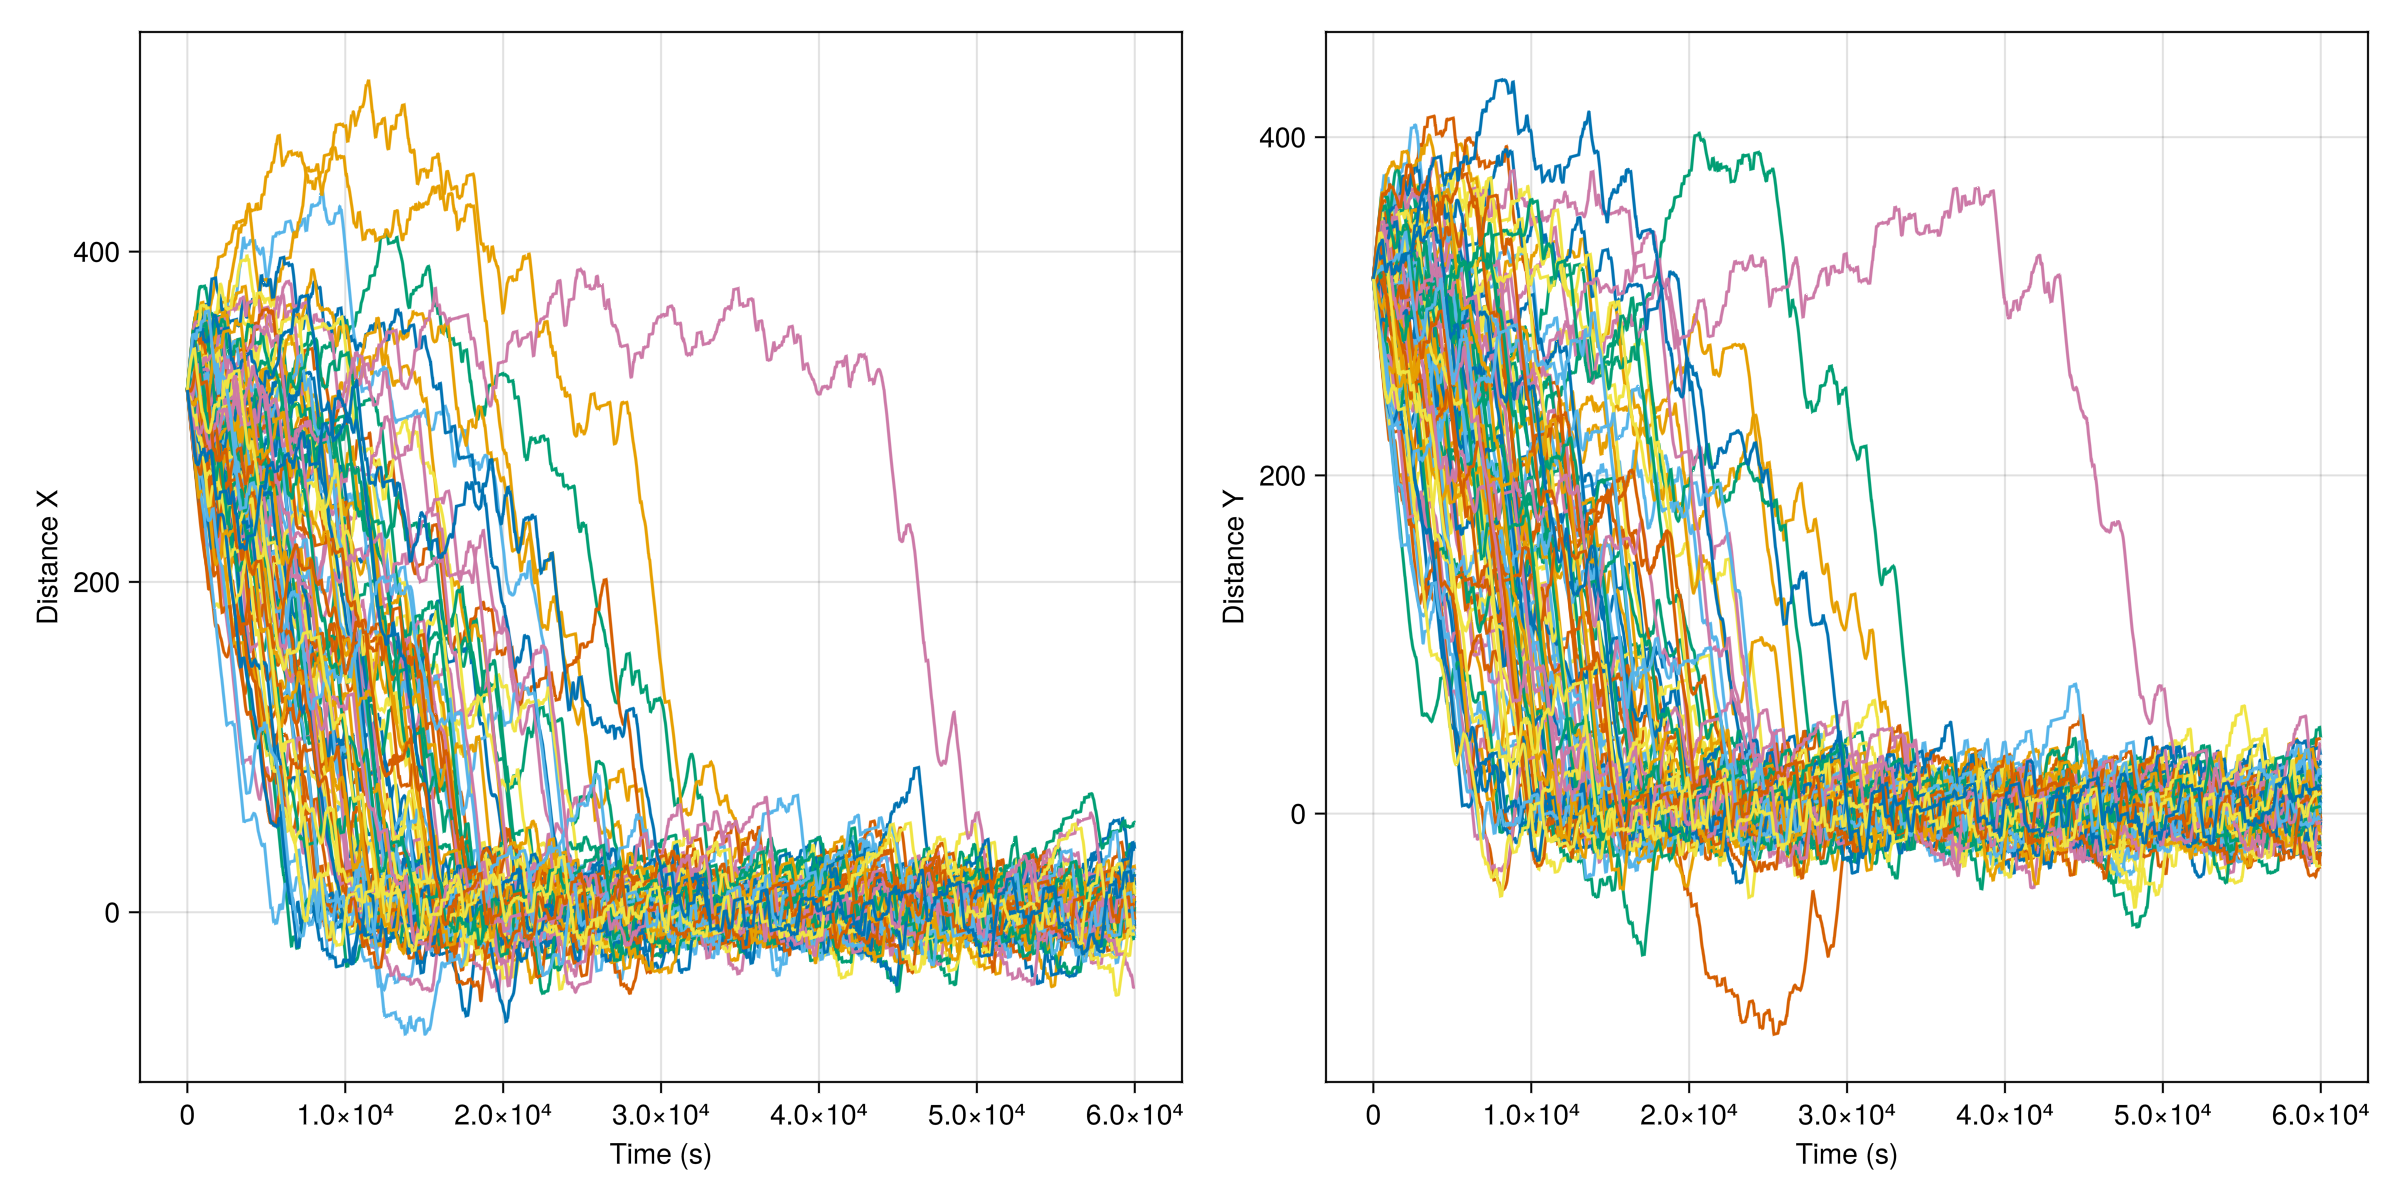

GLMakie.Screen(...)

In [260]:
fig3 = Figure(size=(1200, 600))
ax1 = Axis(fig3[1,1], xlabel="Time (s)", ylabel="Distance X")
ax2 = Axis(fig3[1,2], xlabel="Time (s)", ylabel="Distance Y")



steps = 60000

jldopen("fsb_10.0_lambda_0.25.jld2", "r") do file 
    for agent in 2:100
        x = Float64[] 
        y = Float64[]

        for step in 1:10:steps
            g = file[@sprintf("step_%06d", step)]

            src = 1

            xs = 0
            ys = 0

            x_1 = g["x"][agent]
            y_1 = g["y"][agent]

            # dist = abs(sqrt((x_1 - xs)^2 + (y_1 - ys)^2))
            dist = x_1 - xs
            dist_2 = y_1 - ys

            push!(x, dist)
            push!(y, dist_2)
    

        end

        # lines!(ax1, 1:steps, log.(x))
        lines!(ax1, 1:10:steps, x)
        lines!(ax2, 1:10:steps, y)
        
    end

end
display(fig3)

In [261]:
save("Plots/Fixed_source_model/Trajectories/v10_tm1_025.png", fig3)

In [20]:
df_times = CSV.read("Files_threshold_time.csv", DataFrame)

Row,filename,eq_time,threshold
,String31,Int64,Int64
1,"""fsb_5.0_lambda_0.25.jld2""",3000,50
2,"""fsb_5.0_lambda_0.5.jld2""",2000,50
3,"""fsb_5.0_lambda_0.75.jld2""",1000,50
4,"""fsb_5.0_lambda_1.0.jld2""",1000,50
5,"""fsb_5.0_lambda_2.0.jld2""",1000,50
6,"""fsb_5.0_lambda_3.0.jld2""",1000,50
7,"""fsb_5.0_lambda_4.0.jld2""",1000,50
8,"""fsb_5.0_lambda_5.0.jld2""",1000,50
9,"""fsb_5.0_lambda_6.0.jld2""",1000,50


In [21]:
df_times.filename = replace.(df_times.filename, "\"" => "")

39-element Vector{String}:
 "fsb_5.0_lambda_0.25.jld2"
 "fsb_5.0_lambda_0.5.jld2"
 "fsb_5.0_lambda_0.75.jld2"
 "fsb_5.0_lambda_1.0.jld2"
 "fsb_5.0_lambda_2.0.jld2"
 "fsb_5.0_lambda_3.0.jld2"
 "fsb_5.0_lambda_4.0.jld2"
 "fsb_5.0_lambda_5.0.jld2"
 "fsb_5.0_lambda_6.0.jld2"
 "fsb_5.0_lambda_7.0.jld2"
 ⋮
 "fsb_100.0_lambda_2.0.jld2"
 "fsb_100.0_lambda_3.0.jld2"
 "fsb_100.0_lambda_4.0.jld2"
 "fsb_100.0_lambda_5.0.jld2"
 "fsb_100.0_lambda_6.0.jld2"
 "fsb_100.0_lambda_7.0.jld2"
 "fsb_100.0_lambda_8.0.jld2"
 "fsb_100.0_lambda_9.0.jld2"
 "fsb_100.0_lambda_10.0.jld2"

In [144]:
df_times = CSV.read("df_times_10.csv", DataFrame)
df_times.filename = replace.(df_times.filename, "\"" => "")

13-element Vector{String}:
 "fsb_10.0_lambda_0.25.jld2"
 "fsb_10.0_lambda_0.5.jld2"
 "fsb_10.0_lambda_0.75.jld2"
 "fsb_10.0_lambda_1.0.jld2"
 "fsb_10.0_lambda_2.0.jld2"
 "fsb_10.0_lambda_3.0.jld2"
 "fsb_10.0_lambda_4.0.jld2"
 "fsb_10.0_lambda_5.0.jld2"
 "fsb_10.0_lambda_6.0.jld2"
 "fsb_10.0_lambda_7.0.jld2"
 "fsb_10.0_lambda_8.0.jld2"
 "fsb_10.0_lambda_9.0.jld2"
 "fsb_10.0_lambda_10.0.jld2"

In [22]:
df_times[1, 3] = 75 
df_times[14, 3] = 175 

175

In [146]:
function check_agent(file, step, agent_idx, threshold)

    data = file[@sprintf("step_%06d", step)]
    
    x = data["x"][agent_idx]
    y = data["y"][agent_idx]
    
    return (x <= threshold) && (y <= threshold)
end

check_agent (generic function with 1 method)

In [ ]:
lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
velocities = [5.0, 20.0, 100.0]

N_agents = 1000
end_step = 60000

results = DataFrame(
    filename = String[],
    v = Float64[],
    lambda = Float64[],
    valid_number =  Int[],
    valid_agents = Vector{Vector{Int}}()
)

total_files = length(lambdas) * length(velocities)
file_counter = 0

for v in velocities
    for lambda in lambdas
        
        filename = @sprintf("fsb_%s_lambda_%s.jld2", v, lambda)
        file_counter += 1
        
        println("\n[$file_counter / $total_files] Processing: $filename")
        
        # 🔍 Lookup parameters from df_times
        row = df_times[df_times.filename .== filename, :]
        
        if nrow(row) == 0
            println("  ⚠️ Skipping (not found in df_times)")
            continue
        end
        
        start_step = row.eq_time[1]*10
        threshold_distance = row.threshold[1]
        
        println("  → start_step = $start_step, threshold = $threshold_distance")
        
        valid_agents = Int[]
        
        jldopen(filename, "r") do file
            for agent_idx in 1:N_agents
                is_valid = true
                
                for step in start_step:5:end_step
                    if !check_agent(file, step, agent_idx, threshold_distance)
                        is_valid = false
                        break
                    end
                end
                
                if is_valid
                    push!(valid_agents, agent_idx)
                end
            end
        end
        
        println("  ✔ Found $(length(valid_agents)) valid agents")
        
        push!(results, (
            filename,
            v,
            lambda,
            length(valid_agents),
            copy(valid_agents)
        ))
    end
end


[1 / 39] Processing: fsb_5.0_lambda_0.25.jld2
  → start_step = 30000, threshold = 75
  ✔ Found 953 valid agents


In [ ]:
# --- CONFIGURATION ---
input_file = "fsb_10.0_lambda_0.25.jld2"

start_step = 30000  # Equilibrium start (manually inserted)
end_step = 60000   # End of simulation
threshold_distance = 75 # Your threshold
N_agents = 1000    # Fixed number of agents

# --- HELPER ---
function check_agent(file, step, agent_idx, threshold)

    data = file[@sprintf("step_%06d", step)]
    
    x = data["x"][agent_idx]
    y = data["y"][agent_idx]
    
    return (x <= threshold) && (y <= threshold)
end

# --- PHASE 1: IDENTIFY VALID AGENTS ---
valid_agents = Int[] # Store indices 1 to 1000

println("Phase 1: Checking dispersion for $N_agents agents from step $start_step to $end_step...")

jldopen(input_file, "r") do file
    for agent_idx in 1:N_agents
        is_valid = true
        
        # Check the entire range for this agent
        for step in start_step:5:end_step
            if !check_agent(file, step, agent_idx, threshold_distance)
                is_valid = false
                break # Stop immediately if one step fails
            end
        end
        
        if is_valid
            push!(valid_agents, agent_idx)
        end
    end
end

println("Phase 1 complete. Found $(length(valid_agents)) valid agents out of $N_agents.")

Phase 1: Checking dispersion for 1000 agents from step 30000 to 60000...
Phase 1 complete. Found 958 valid agents out of 1000.


In [263]:
filename = "fsb_10.0_lambda_0.25.jld2"
start_step = 1
end_step = 60000
steps = end_step - start_step
steps_vec = Int[]
agents_vec = Int32[]
x_vec = Float64[]
y_vec = Float64[]

jldopen(filename, "r") do file
    for (idx, agent) in enumerate(valid_agents)
        for step in start_step:10:end_step
            g = file[@sprintf("step_%06d", step)]
            x = g["x"][agent]
            y = g["y"][agent]

            push!(steps_vec, step)
            push!(agents_vec, agent)
            push!(x_vec, x)
            push!(y_vec, y)
        end
    end
end

df_v10_025 = DataFrame(
    step = steps_vec,
    agent = agents_vec,
    x = x_vec,
    y = y_vec
)


Row,step,agent,x,y
,Int64,Int32,Float64,Float64
1,1,1,0.0,0.0
2,11,1,0.0,0.0
3,21,1,0.0,0.0
4,31,1,0.0,0.0
5,41,1,0.0,0.0
6,51,1,0.0,0.0
7,61,1,0.0,0.0
8,71,1,0.0,0.0
9,81,1,0.0,0.0


In [147]:
dfs_10 = Dict{Tuple{Float64, Float64}, DataFrame}()

lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
velocities = [10.0]
N_agents = 1000
end_step = 60000

for v in velocities
    for lambda in lambdas

        filename = @sprintf("fsb_%s_lambda_%s.jld2", v, lambda)
        println("Processing $filename")

        # lookup metadata
        row = df_times[df_times.filename .== filename, :]

        if nrow(row) == 0
            println("  ⚠️ Skipping (not found in df_times)")
            continue
        end

        start_step = row.eq_time[1]*10
        threshold_distance = row.threshold[1]

        # -----------------------------
        # STEP 1: find valid agents
        # -----------------------------
        valid_agents = Int[]

        jldopen(filename, "r") do file
            for agent_idx in 1:N_agents
                is_valid = true

                for step in start_step:5:end_step
                    if !check_agent(file, step, agent_idx, threshold_distance)
                        is_valid = false
                        break
                    end
                end

                if is_valid
                    push!(valid_agents, agent_idx)
                end
            end
        end

        println("  ✔ valid agents: $(length(valid_agents))")

        # -----------------------------
        # STEP 2: extract trajectories
        # -----------------------------
        steps_vec = Int[]
        agents_vec = Int[]
        x_vec = Float64[]
        y_vec = Float64[]

        jldopen(filename, "r") do file
            for agent in valid_agents
                for step in 1:10:end_step
                    g = file[@sprintf("step_%06d", step)]

                    push!(steps_vec, step)
                    push!(agents_vec, agent)
                    push!(x_vec, g["x"][agent])
                    push!(y_vec, g["y"][agent])
                end
            end
        end

        df = DataFrame(
            step = steps_vec,
            agent = agents_vec,
            x = x_vec,
            y = y_vec
        )

        # store in dict
        dfs_10[(v, lambda)] = df
    end
end

Processing fsb_10.0_lambda_0.25.jld2
  ✔ valid agents: 948
Processing fsb_10.0_lambda_0.5.jld2
  ✔ valid agents: 996
Processing fsb_10.0_lambda_0.75.jld2
  ✔ valid agents: 988
Processing fsb_10.0_lambda_1.0.jld2
  ✔ valid agents: 993
Processing fsb_10.0_lambda_2.0.jld2
  ✔ valid agents: 989
Processing fsb_10.0_lambda_3.0.jld2
  ✔ valid agents: 948
Processing fsb_10.0_lambda_4.0.jld2
  ✔ valid agents: 922
Processing fsb_10.0_lambda_5.0.jld2
  ✔ valid agents: 834
Processing fsb_10.0_lambda_6.0.jld2
  ✔ valid agents: 738
Processing fsb_10.0_lambda_7.0.jld2
  ✔ valid agents: 612
Processing fsb_10.0_lambda_8.0.jld2
  ✔ valid agents: 504
Processing fsb_10.0_lambda_9.0.jld2
  ✔ valid agents: 381
Processing fsb_10.0_lambda_10.0.jld2
  ✔ valid agents: 264


In [51]:
@save "dfs.jld2" dfs

In [2]:
@load "dfs.jld2" dfs

1-element Vector{Symbol}:
 :dfs

In [3]:
@load "metrics.jld2" metrics

1-element Vector{Symbol}:
 :metrics

In [52]:
@save "metrics.jld2" metrics


# All automated

In [128]:
function linear_fit(x, y)
    """Simple linear regression: y = a + b*x"""
    n = length(x)
    sum_x = sum(x)
    sum_y = sum(y)
    sum_xy = sum(x .* y)
    sum_x2 = sum(x.^2)
    
    slope = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x^2)
    intercept = (sum_y - slope * sum_x) / n
    
    return slope, intercept
end

linear_fit (generic function with 1 method)

# Visualize

In [148]:
function plot_descent_macro(dfs, df_times, velocities, lambdas)

for v in velocities

    fig = Figure(size=(1800, 1200))
    # fig_title = Label(fig[0, :], "Descent regions — v = $v")

    idx = 1

    for λ in lambdas

        df = dfs[(v, λ)]
        filename = @sprintf("fsb_%s_lambda_%s.jld2", v, λ)

        row = df_times[df_times.filename .== filename, :]
        if nrow(row) == 0
            continue
        end

        eq_step = row.eq_time[1]*10

        descent = df[df.step .< eq_step, :]
        if nrow(descent) == 0
            continue
        end

        # group by step
        g = groupby(descent, :step)

        dist = combine(g, :x => (x -> abs(mean(x))) => :m)

        t = collect(1:nrow(dist)) .* 0.01
        y = log.(dist.m)

        r = fld(idx-1, 4) + 1
        c = mod1(idx, 4)

        ax = Axis(fig[r, c],
            title = "λ = $λ",
            xlabel = "t",
            ylabel = "log|x|"
        )

        lines!(ax, t, y)

        idx += 1
    end

    save("descent_macro_v$(v).png", fig)
end

end

plot_descent_macro (generic function with 1 method)

In [149]:
plot_descent_macro(dfs_10, df_times, velocities, lambdas)

In [150]:
df_times.fit_start = Union{Int, Missing}[missing for _ in 1:nrow(df_times)]
df_times.fit_end   = Union{Int, Missing}[missing for _ in 1:nrow(df_times)]

function set_fit_window!(df_times, filename, start_idx, end_idx)
    df_times[df_times.filename .== filename, :fit_start] .= start_idx
    df_times[df_times.filename .== filename, :fit_end]   .= end_idx
end

set_fit_window! (generic function with 1 method)

In [125]:
df_times.fit_end[13]

missing

In [160]:
set_fit_window!(df_times, "fsb_10.0_lambda_0.25.jld2", 1, 3000)
set_fit_window!(df_times, "fsb_10.0_lambda_0.5.jld2", 1, 1500)
set_fit_window!(df_times, "fsb_10.0_lambda_0.75.jld2", 1, 600)
set_fit_window!(df_times, "fsb_10.0_lambda_1.0.jld2", 1, 600)
set_fit_window!(df_times, "fsb_10.0_lambda_2.0.jld2", 1, 400)
set_fit_window!(df_times, "fsb_10.0_lambda_3.0.jld2", 1, 375)
set_fit_window!(df_times, "fsb_10.0_lambda_4.0.jld2", 1, 200)
set_fit_window!(df_times, "fsb_10.0_lambda_5.0.jld2", 1, 160)
set_fit_window!(df_times, "fsb_10.0_lambda_6.0.jld2", 1, 160)
set_fit_window!(df_times, "fsb_10.0_lambda_7.0.jld2", 1, 30)
set_fit_window!(df_times, "fsb_10.0_lambda_8.0.jld2", 1, 20)
set_fit_window!(df_times, "fsb_10.0_lambda_9.0.jld2", 1, 20)
set_fit_window!(df_times, "fsb_10.0_lambda_10.0.jld2", 1, 20)


1-element view(::Vector{Union{Missing, Int64}}, [13]) with eltype Union{Missing, Int64}:
 20

In [161]:
metrics_10 = DataFrame(
    v = Float64[],
    lambda = Float64[],
    mu_x = Float64[],
    mu_y = Float64[],
    sigma_x = Float64[],
    sigma_y = Float64[],
    k_x = Float64[],
    k_y = Float64[]
)

Row,v,lambda,mu_x,mu_y,sigma_x,sigma_y,k_x,k_y
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64


In [162]:
for ((v, λ), df) in dfs_10

    filename = @sprintf("fsb_%s_lambda_%s.jld2", v, λ)

    row = df_times[df_times.filename .== filename, :]
    if nrow(row) == 0
        continue
    end

    eq_step = row.eq_time[1]*10
    fit_start = row.fit_start[1]
    fit_end   = row.fit_end[1]

    if ismissing(eq_step) || ismissing(fit_start) || ismissing(fit_end)
        println("Skipping $filename (missing params)")
        continue
    end

    # =========================
    # SPLIT DATA
    # =========================
    eq = df[df.step .>= eq_step, :]
    descent = df[df.step .< eq_step, :]

    # =========================
    # EQUILIBRIUM STATS
    # =========================
    mu_x = mean(eq.x)
    mu_y = mean(eq.y)
    sigma_x = std(eq.x)
    sigma_y = std(eq.y)

    fig = Figure(size=(900, 500))

    ax1 = Axis(fig[1, 1], title="Eq X", xlabel="x")
    ax2 = Axis(fig[1, 2], title="Eq Y", xlabel="y")

    hist!(ax1, eq.x, normalization=:pdf, bins=50)
    hist!(ax2, eq.y, normalization=:pdf, bins=50)

    xfit = range(minimum(eq.x), maximum(eq.x), length=200)
    yfit = range(minimum(eq.y), maximum(eq.y), length=200)

    lines!(ax1, xfit, pdf.(Distributions.Normal(mu_x, sigma_x), xfit), color=:red)
    lines!(ax2, yfit, pdf.(Distributions.Normal(mu_y, sigma_y), yfit), color=:red)

    save("eq_v$(v)_l$(λ).png", fig)

    # =========================
    # DESCENT STATS
    # =========================
    g = groupby(descent, :step)
    dist = combine(g, :x => (x -> abs(mean(x))) => :m)

    logx = log.(dist.m)
    t = collect(1:length(dist.m))

    if fit_end > length(t)
        println("Fit window out of range for $filename")
        continue
    end

    slope_x, intercept_x = linear_fit(t[fit_start:fit_end], logx[fit_start:fit_end])
    k_x = -slope_x

    # (optional: y identical structure if needed)
    g2 = groupby(descent, :step)
    dist_y = combine(g2, :y => (y -> abs(mean(y))) => :m)
    logy = log.(dist_y.m)

    slope_y, intercept_y = linear_fit(t[fit_start:fit_end], logy[fit_start:fit_end])
    k_y = -slope_y

    fig2 = Figure(size=(1200, 500))

    ax3 = Axis(fig2[1, 1], title="Descent X", xlabel="t", ylabel="log|x|")
    ax4 = Axis(fig2[1, 2], title="Descent Y", xlabel="t", ylabel="log|y|")

    lines!(ax3, t, logx, color=:cyan)
    lines!(ax4, t, logy, color=:cyan)
    
    lines!(ax3, t[fit_start:fit_end], logx[fit_start:fit_end], color=:blue)
    lines!(ax4, t[fit_start:fit_end], logy[fit_start:fit_end], color=:blue)

    lines!(ax3, t[fit_start:fit_end],
        intercept_x .+ slope_x .* t[fit_start:fit_end],
        color=:red, linestyle=:dash)

    lines!(ax4, t[fit_start:fit_end],
        intercept_y .+ slope_y .* t[fit_start:fit_end],
        color=:red, linestyle=:dash)

    save("descent_fit_v$(v)_l$(λ).png", fig2)

    # =========================
    # STORE METRICS
    # =========================
    push!(metrics_10, (
        v,
        λ,
        mu_x,
        mu_y,
        sigma_x,
        sigma_y,
        k_x,
        k_y
    ))
end

In [61]:
mask = (metrics.v .== 100.0) .& (metrics.lambda .== 7.0)

# Update the specific columns
metrics.sigma_x[mask]



1-element Vector{Float64}:
 99.70483256055755

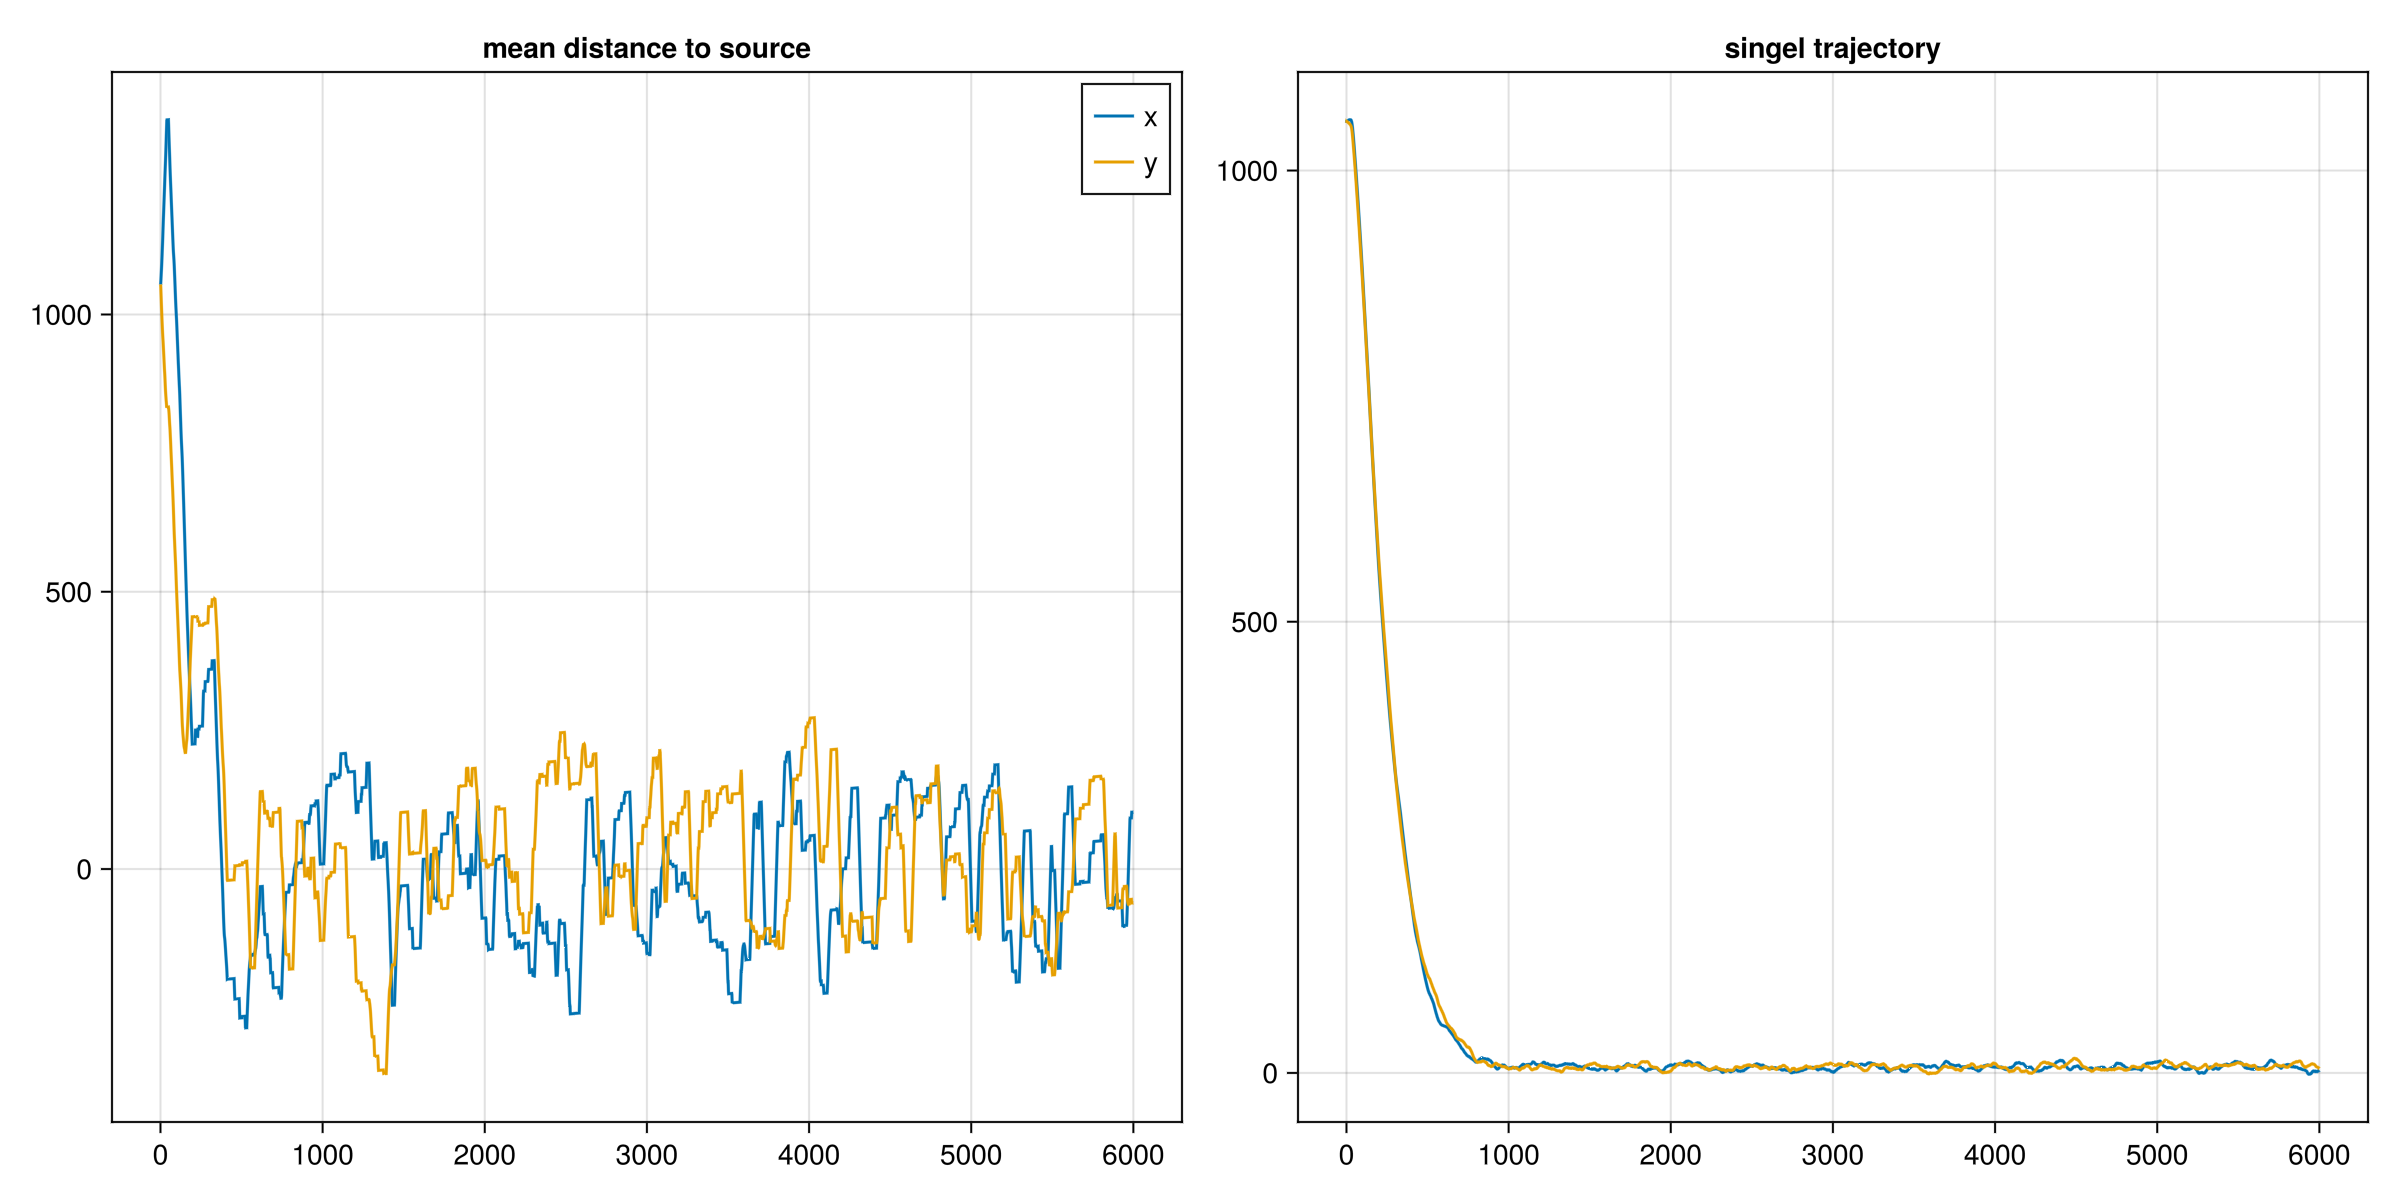

In [331]:
df = combined_dfs[(100.0, 0.75)]
λ = 1.0
v = 100.0
fig = Figure(size=(1200, 600))
ax= Axis(fig[1,1], title = "mean distance to source")
ax2= Axis(fig[1,2], title = "singel trajectory")
grouped = groupby(df, :agent)
grouped_t = groupby(df, :step)
data = grouped[400]
mean_x = Float64[]
mean_y = Float64[]

for i in 1:length(grouped_t)
    data_1 = grouped_t[i]
    push!(mean_x, mean(data_1.x))
    push!(mean_y, mean(data_1.y))
end

lines!(ax, 1:length(grouped_t), data.x, label = "x")
lines!(ax, 1:length(grouped_t), data.y, label = "y")
lines!(ax2, 1:length(grouped_t), mean_x, label = "x")
lines!(ax2, 1:length(grouped_t), mean_y, label = "y")
axislegend(ax, position = :rt)
fig

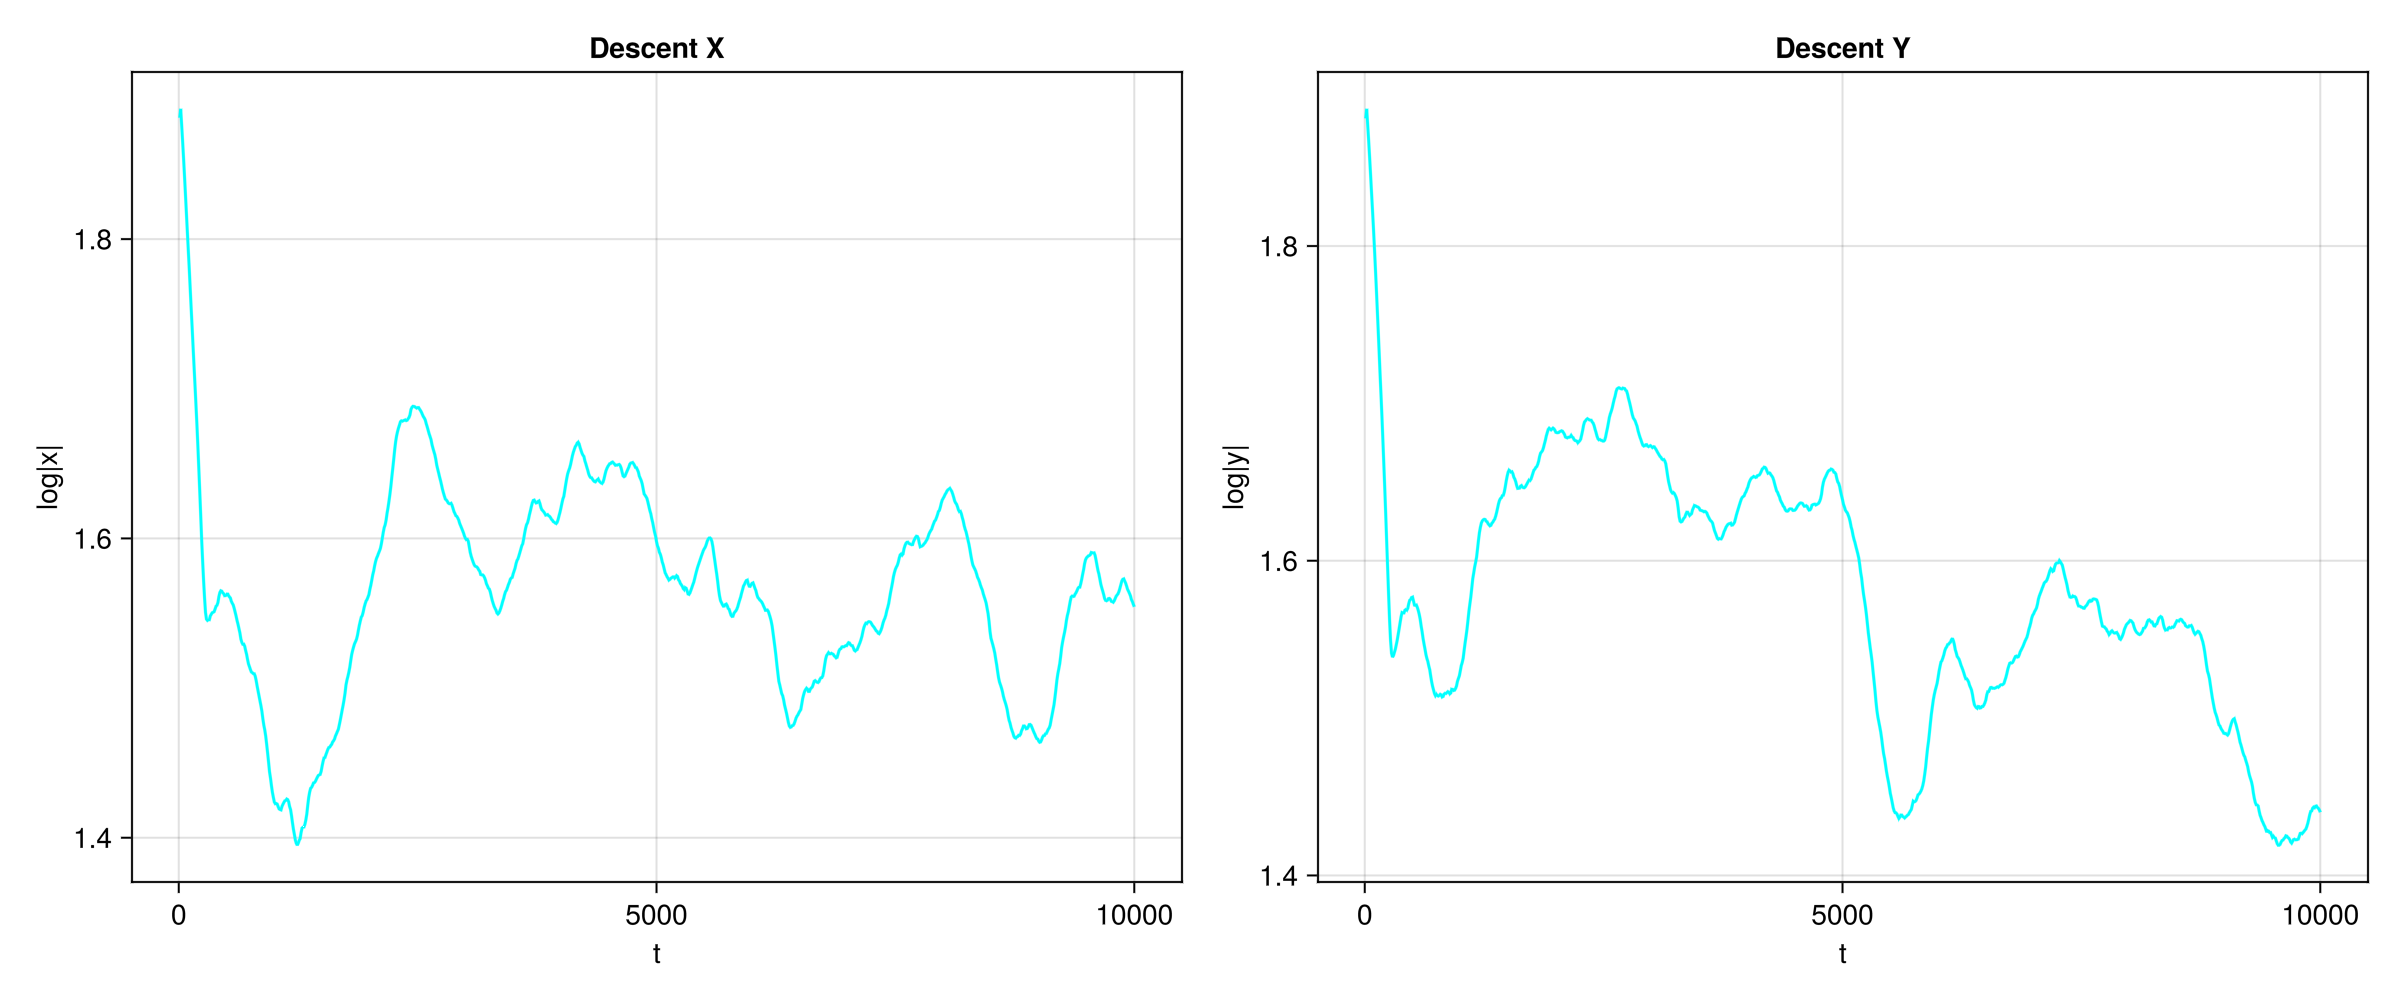

In [313]:
df = combined_dfs[(5.0, 6.0)]
λ = 6.0
v = 5.0
filename = @sprintf("fsb_%s_lambda_%s.jld2", v, λ)

row = df_times[df_times.filename .== filename, :]
# eq_step =(row.eq_time[1])
eq_step = 1000
# fit_start = (row.fit_start[1])
# fit_end   = (row.fit_end[1])

grouped = groupby(df, :step)
eq = grouped[eq_step:end]
df_subset = DataFrame(eq)
    # df_subset = df_v10_025[3000:end, :]

    # # 2. Identify rows in this subset where x > 75 OR y > 75
bad_rows_mask = (df_subset.x .> 40) .| (df_subset.y .> 40) .| (df_subset.x .< -40) .| (df_subset.y .< -40)

    # # 3. Extract the unique agents from these "bad" rows
bad_agents = unique(df_subset[bad_rows_mask, :agent])

    # # 4. Filter the original full dataframe to remove ALL rows for these agents
    # # We keep rows where the agent is NOT in the bad_agents list
df_clean = filter(row -> !(row.agent in bad_agents), df)
println(maximum(df_clean.x))
    # # # Optional: Check results
println("Agents flagged based on steps 1000+: ", bad_agents)
println("Rows in original: ", nrow(df))
println("Rows after cleaning: ", nrow(df_clean))


step_groups = groupby(df_clean, :step)
eq = step_groups[eq_step:end]
equilibrium = DataFrame(eq)

descent = step_groups[1:eq_step]
# g = groupby(descent, :step)
dist = combine(descent, :x => (x -> abs(mean(x))) => :m)

logx = log.(dist.m)
t = collect(1:length(dist.m))*10

    # slope_x, intercept_x = linear_fit(t[fit_start:fit_end], logx[fit_start:fit_end])
    k_x = -slope_x

    # (optional: y identical structure if needed)
    # g2 = groupby(descent, :step)
    dist_y = combine(descent, :y => (y -> abs(mean(y))) => :m)
    logy = log.(dist_y.m)

    # slope_y, intercept_y = linear_fit(t[fit_start:fit_end], logy[fit_start:fit_end])
    k_y = -slope_y

    fig2 = Figure(size=(1200, 500))

    ax3 = Axis(fig2[1, 1], title="Descent X", xlabel="t", ylabel="log|x|")
    ax4 = Axis(fig2[1, 2], title="Descent Y", xlabel="t", ylabel="log|y|")

    lines!(ax3, t, logx, color=:cyan)
    lines!(ax4, t, logy, color=:cyan)
    
    # lines!(ax3, t[fit_start:fit_end], logx[fit_start:fit_end], color=:blue)
    # lines!(ax4, t[fit_start:fit_end], logy[fit_start:fit_end], color=:blue)

    # lines!(ax3, t[fit_start:fit_end],
    #     intercept_x .+ slope_x .* t[fit_start:fit_end],
    #     color=:red, linestyle=:dash)

    # lines!(ax4, t[fit_start:fit_end],
    #     intercept_y .+ slope_y .* t[fit_start:fit_end],
    #     color=:red, linestyle=:dash)
fig2

# mu_x = mean(equilibrium.x)
# mu_y = mean(equilibrium.y)
# sigma_x = std(equilibrium.x)
# sigma_y = std(equilibrium.y)

#    fig = Figure(size=(900, 500))



#    ax1 = Axis(fig[1, 1], title="Eq X", xlabel="x")
#    ax2 = Axis(fig[1, 2], title="Eq Y", xlabel="y")

#    hist!(ax1, equilibrium.x, normalization=:pdf, bins=50)
#    hist!(ax2, equilibrium.y, normalization=:pdf, bins=50)

#    xfit = range(minimum(equilibrium.x), maximum(equilibrium.x), length=200)
#    yfit = range(minimum(equilibrium.y), maximum(equilibrium.y), length=200)

#    lines!(ax1, xfit, pdf.(Distributions.Normal(mu_x, sigma_x), xfit), color=:red, label = "$(round(sigma_x, digits = 3))")
#    lines!(ax2, yfit, pdf.(Distributions.Normal(mu_y, sigma_y), yfit), color=:red, label = "$(round(sigma_y, digits = 3))")
# #    axislegend(ax1, position = :lt)
# #    axislegend(ax2, position = :lt)


#    fig

In [252]:
save("Plots/Fixed_source_model/v100/eq_v10.0_l10.0.png", fig)

In [243]:
mask = (metrics_10.v .== v) .& (metrics_10.lambda .== λ)
metrics_10.sigma_x[mask]

1-element Vector{Float64}:
 7.602275504878369

In [253]:
mask = (metrics_10.v .== v) .& (metrics_10.lambda .== λ)

# Update the specific columns
metrics_10.mu_x[mask] .= mu_x
metrics_10.mu_y[mask] .= mu_y
metrics_10.sigma_x[mask] .= sigma_x
metrics_10.sigma_y[mask] .= sigma_y


1-element view(::Vector{Float64}, [10]) with eltype Float64:
 6.845689562338433

# Metrics plot

In [260]:
@save "metrics_combined.jld2" metrics_combined

In [339]:
@save "combined_dfs.jlds" combined_dfs

In [340]:
@save "dc_delta.jld2" dc_delta

In [261]:
@save "dfs_10.jld2" dfs_10

In [255]:
metrics_combined = vcat(metrics, metrics_10)

Row,v,lambda,mu_x,mu_y,sigma_x,sigma_y,k_x,k_y
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,20.0,4.0,4.12085,4.20449,13.8417,13.6265,0.00504218,0.00547748
2,100.0,9.0,8.39487,8.52574,52.4909,52.2096,0.0157368,0.0124633
3,5.0,9.0,0.546728,1.73051,17.1098,16.3216,0.0185338,0.0214704
4,20.0,9.0,4.49154,3.80964,13.0998,20.0125,0.0180716,0.0235423
5,100.0,5.0,8.19036,8.64306,60.1512,60.0034,0.00745649,0.00661533
6,5.0,5.0,4.86336,4.82832,7.05832,6.82974,0.00404968,0.00352136
7,20.0,5.0,4.63605,4.33942,13.2483,13.1891,0.00577897,0.00578884
8,100.0,6.0,8.65329,8.52334,57.7068,57.7475,0.00568984,0.00644998
9,5.0,6.0,4.67125,4.67106,8.08399,7.55588,0.00340852,0.00426279


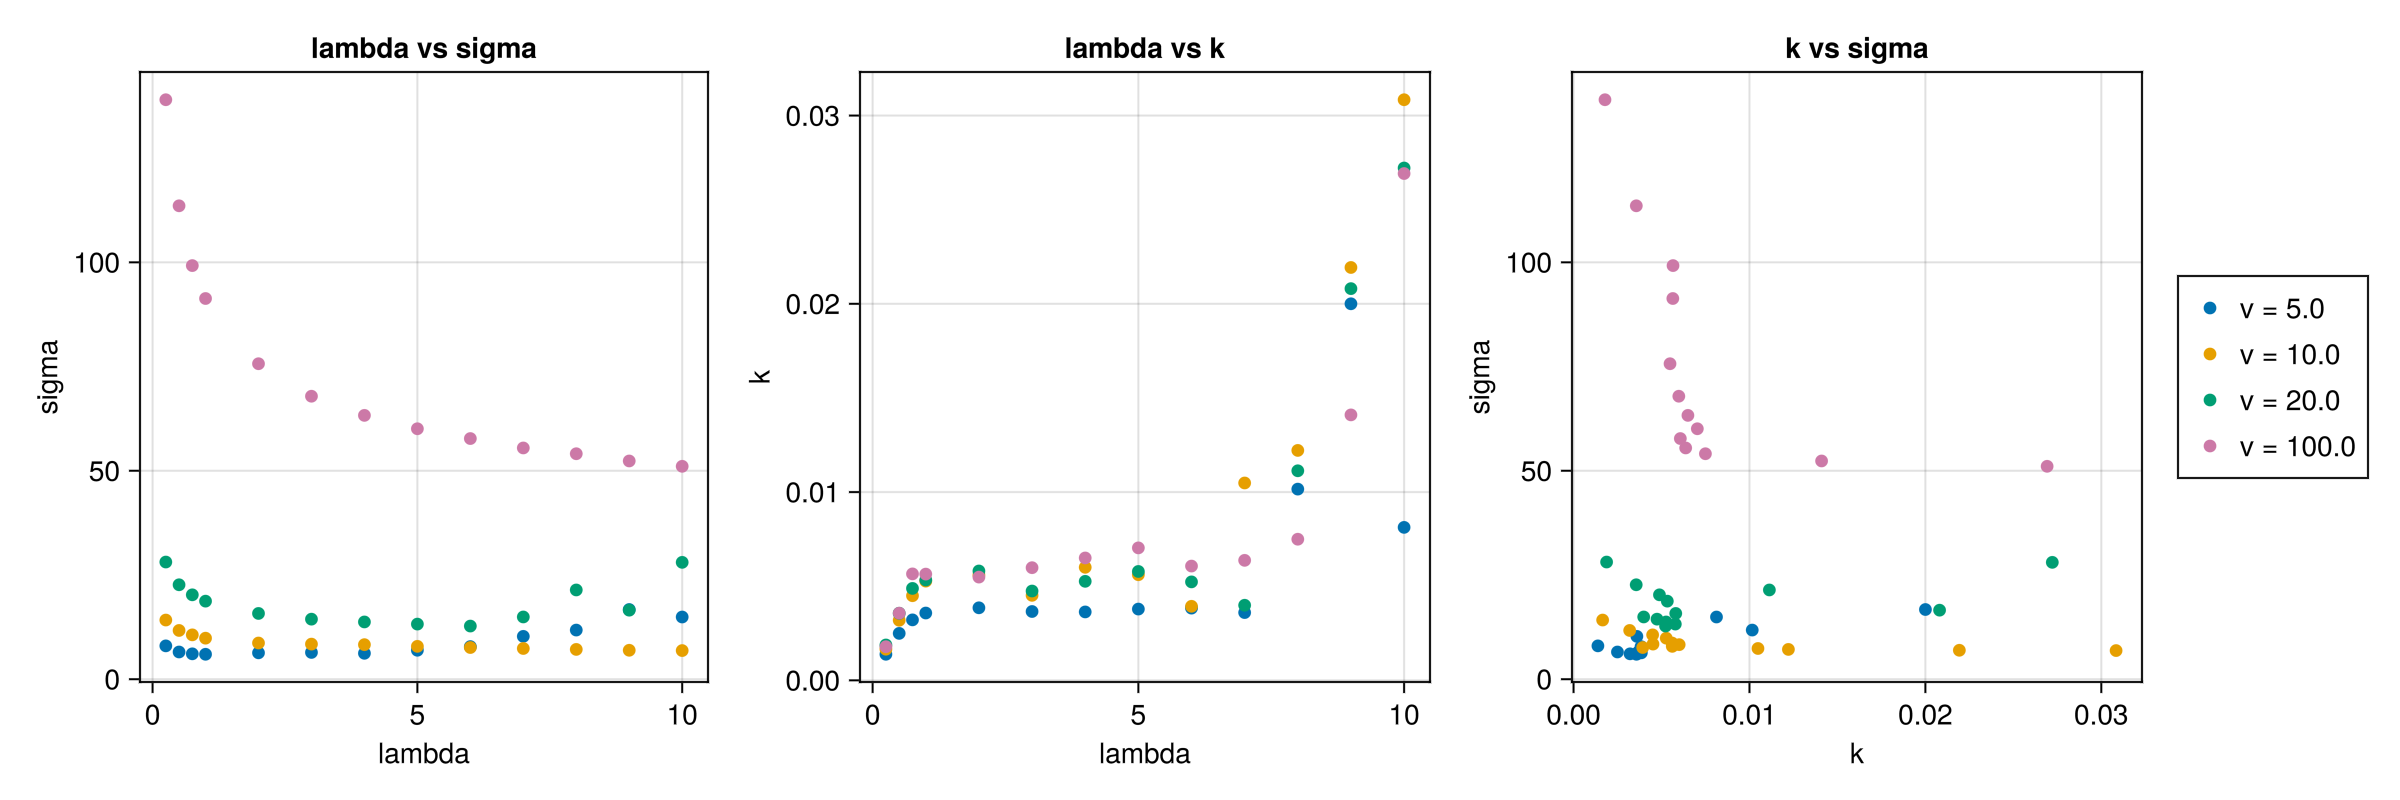

In [258]:
lambda = metrics_combined.lambda
sigma = (metrics_combined.sigma_x .+ metrics_combined.sigma_y) ./ 2
k     = (metrics_combined.k_x .+ metrics_combined.k_y) ./ 2
vvals = metrics_combined.v

fig = Figure(size = (1200, 400))

ax1 = Axis(fig[1, 1],
    xlabel = "lambda",
    ylabel = "sigma",
    title = "lambda vs sigma"
)

ax2 = Axis(fig[1, 2],
    xlabel = "lambda",
    ylabel = "k",
    title = "lambda vs k"
)

ax3 = Axis(fig[1, 3],
    xlabel = "k",
    ylabel = "sigma",
    title = "k vs sigma"
)

# unique velocities
unique_v = [5.0, 10.0, 20.0, 100.0]

# choose a color palette
colors = Makie.wong_colors()

for (i, v) in enumerate(unique_v)

    idx = findall(==(v), vvals)

    c = colors[i]

    scatter!(ax1, lambda[idx], sigma[idx],
        color = c,
        label = "v = $v"
    )

    scatter!(ax2, lambda[idx], k[idx],
        color = c,
        label = "v = $v"
    )

    scatter!(ax3, k[idx], sigma[idx],
        color = c,
        label = "v = $v"
    )
end

leg = Legend(fig[1,4], ax1)

fig

In [259]:
save("Plots/Fixed_source_model/L_K_D_all.png", fig)

# Histogram

In [318]:
# 1. Define the subset starting from step 1000
grouped = groupby(df_v10_8, :step)
eq = grouped[1000:end]
df_subset = DataFrame(eq)
# df_subset = df_v10_025[3000:end, :]

# 2. Identify rows in this subset where x > 75 OR y > 75
bad_rows_mask = (df_subset.x .> 75) .| (df_subset.y .> 75)

# 3. Extract the unique agents from these "bad" rows
bad_agents = unique(df_subset[bad_rows_mask, :agent])

# 4. Filter the original full dataframe to remove ALL rows for these agents
# We keep rows where the agent is NOT in the bad_agents list
df_clean = filter(row -> !(row.agent in bad_agents), df_v10_025)

# Optional: Check results
println("Agents flagged based on steps 1000+: ", bad_agents)
println("Rows in original: ", nrow(df_v10_025))
println("Rows after cleaning: ", nrow(df_clean))

Agents flagged based on steps 1000+: Int32[138, 213, 261, 347, 373, 384, 412, 428, 483, 555, 590, 606, 611, 729, 781, 935, 286, 254, 72, 843, 549, 616, 237, 20, 675, 578, 414, 741, 470, 79, 81, 36, 385, 610, 527, 733, 360, 885, 969, 465, 714, 171, 350, 386, 695, 93, 567, 693, 946, 658, 927, 5, 2, 722, 499, 905, 238, 65, 903, 702, 735, 178, 361, 233, 450]
Rows in original: 5748000
Rows after cleaning: 5358000


In [319]:
step_groups = groupby(df_clean, :step)
descent = step_groups[1:1000]

Row,step,agent,x,y
,Int64,Int32,Float64,Float64
1,1,1,0.0,0.0
2,1,3,316.228,316.228
3,1,6,316.228,316.228
4,1,7,316.228,316.228
5,1,8,316.228,316.228
6,1,9,316.228,316.228
7,1,11,316.228,316.228
8,1,12,316.228,316.228
9,1,13,316.228,316.228


In [ ]:
step_groups = groupby(df_clean, :step)
eq = step_groups[1001:end]
equilibrium = DataFrame(eq)

Row,step,agent,x,y
,Int64,Int32,Float64,Float64
1,10001,1,0.0,0.0
2,10001,3,14.3694,-12.4205
3,10001,6,402.631,247.039
4,10001,7,144.078,28.9698
5,10001,8,177.185,131.407
6,10001,9,5.635,6.60195
7,10001,11,95.9675,49.951
8,10001,12,222.806,141.202
9,10001,13,44.3061,160.896


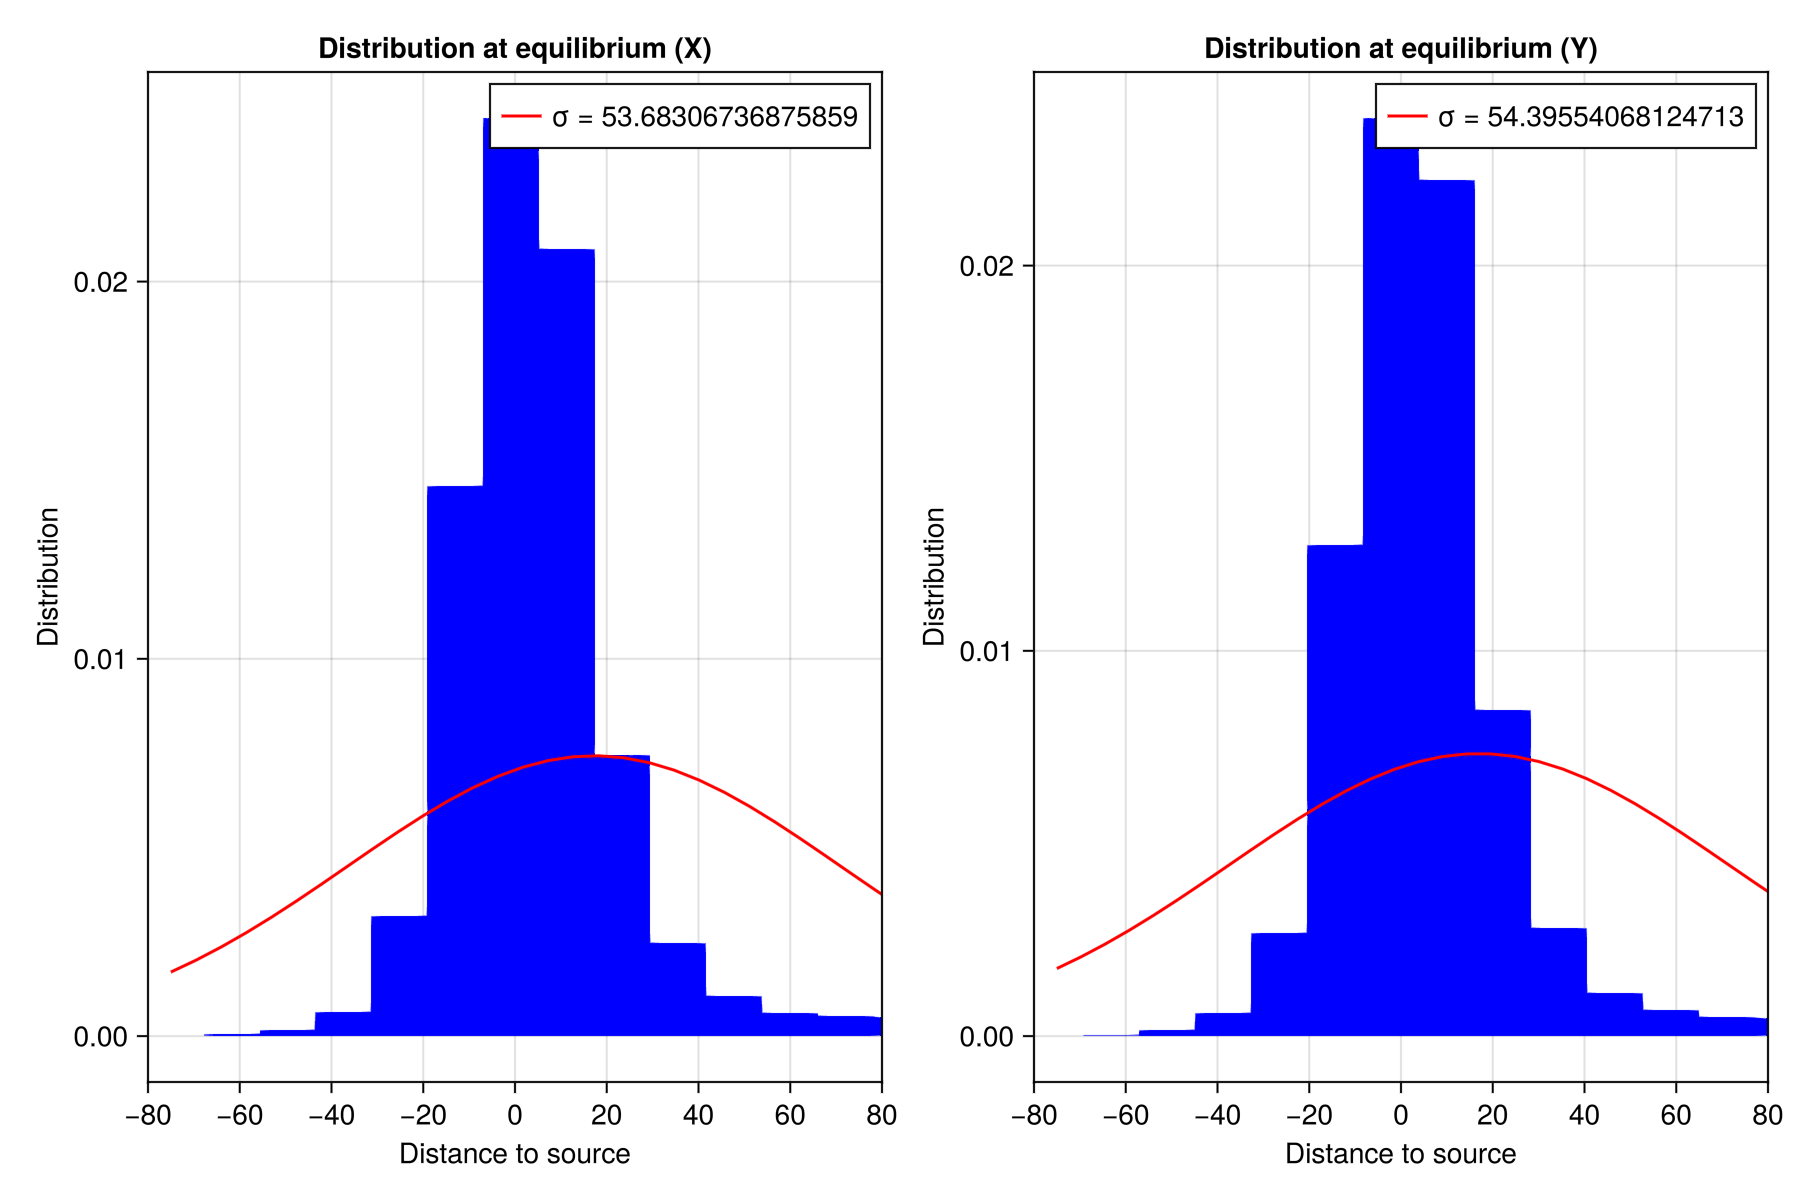

In [317]:
fig = Figure(size=(900, 600))
ax = Axis(fig[1,1], title = "Distribution at equilibrium (X)", xlabel = "Distance to source", ylabel = "Distribution")
ax1 = Axis(fig[1,2], title = "Distribution at equilibrium (Y)", xlabel = "Distance to source", ylabel = "Distribution")

# dist = sqrt.((df_v10_3[1001:end, 2]).^2 .+ (df_v10_3[2:end, 3]).^2)
hist!(ax, equilibrium[:,3], normalization = :pdf, bins = 50, color = :blue)
hist!(ax1, equilibrium[:, 4], normalization = :pdf, bins = 50, color = :blue)

# # Fitting
mu_x = mean(equilibrium[:, 3])
mu_y = mean(equilibrium[:, 4])
sigma_x = std(equilibrium[:, 3])
sigma_y = std(equilibrium[:, 4])
x_fit = range(-75, stop=maximum(equilibrium[:, 3])*1.2, length=125)
y_fit = range(-75, stop=maximum(equilibrium[:, 4])*1.2, length=125)
gaussian_pdf_x = pdf.(Distributions.Normal(mu_x, sigma_x), x_fit)
gaussian_pdf_y = pdf.(Distributions.Normal(mu_y, sigma_y), y_fit)
lines!(ax, x_fit, gaussian_pdf_x, color = :red, label = "σ = $sigma_x")
lines!(ax1, y_fit, gaussian_pdf_y, color = :red, label = "σ = $sigma_y")
axislegend(ax, position = :rt)
axislegend(ax1, position = :rt)
xlims!(ax, -80, 80)
xlims!(ax1, -80, 80)
fig


In [308]:
save("Plots/Fixed_source_model/v10/Subpoblacio_hist_x_y/Lambda_8.png", fig)

# Log lin


In [17]:
function linear_fit(x, y)
    """Simple linear regression: y = a + b*x"""
    n = length(x)
    sum_x = sum(x)
    sum_y = sum(y)
    sum_xy = sum(x .* y)
    sum_x2 = sum(x.^2)
    
    slope = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x^2)
    intercept = (sum_y - slope * sum_x) / n
    
    return slope, intercept
end

linear_fit (generic function with 1 method)

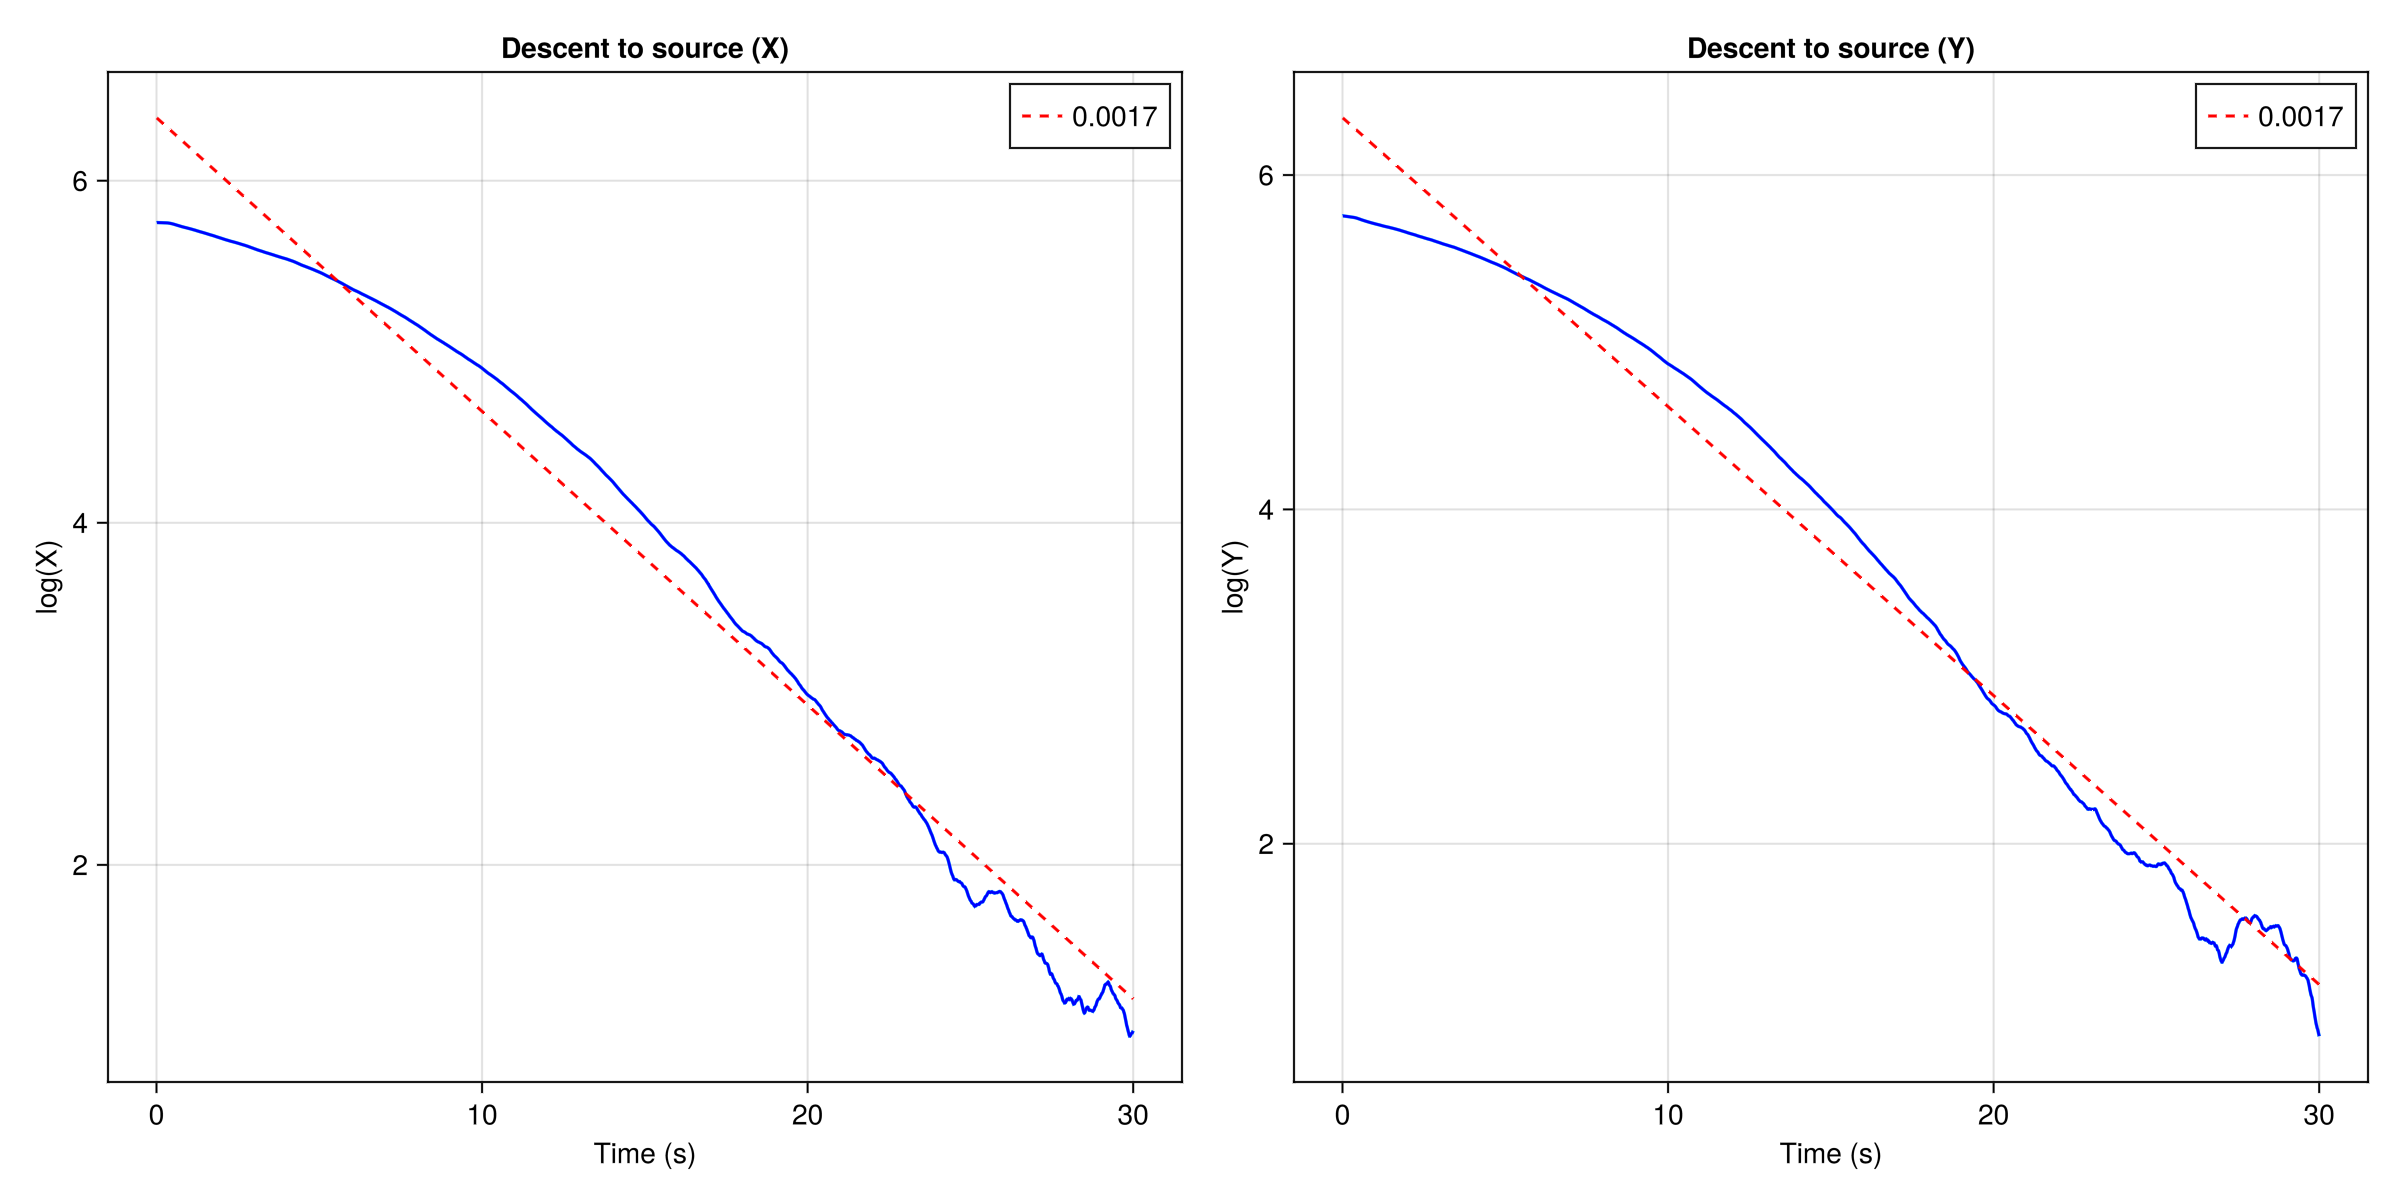

In [302]:
fig2 = Figure(size = (1200, 600))
ax = Axis(fig2[1, 1], title = "Descent to source (X)", xlabel = "Time (s)", ylabel = "log(X)")
ax2 = Axis(fig2[1, 2], title = "Descent to source (Y)", xlabel = "Time (s)", ylabel = "log(Y)")
# df_v10_1[rows, colms]
dist_x = Float64[]
dist_y = Float64[]


# groups = groupby(descent, :step)

for i in 1:length(descent)
    step = descent[i]
    push!(dist_x, abs(mean(step[:, 3])))
    push!(dist_y, abs(mean(step[:, 4])))
end
start_x = 1
end_x = 3000
time_vec = 1:length(descent)
lines!(ax, (1:length(descent))*0.01, log.(dist_x), color = :cyan)
lines!(ax, (time_vec[start_x:end_x])*0.01, log.(dist_x[start_x:end_x]), color = :blue)
lines!(ax2, (1:length(descent))*0.01, log.(dist_y), color = :cyan)
lines!(ax2, (time_vec[start_x:end_x])*0.01, log.(dist_y[start_x:end_x]), color = :blue)

# Fitting
slope_x, intercept_x = linear_fit(time_vec[start_x:end_x], log.(dist_x[start_x:end_x]))
slope_y, intercept_y = linear_fit(time_vec[start_x:end_x], log.(dist_y[start_x:end_x]))

fitted_line_x = [intercept_x + slope_x * t for t in time_vec]
fitted_line_y = [intercept_y + slope_y * t for t in time_vec]
k_x = - slope_x
k_y = - slope_y

lines!(ax, time_vec[start_x:end_x]*0.01, fitted_line_x[start_x:end_x], label = "$(round(k_x, digits = 4))", color = :red, linestyle = :dash)
lines!(ax2, time_vec[start_x:end_x]*0.01, fitted_line_y[start_x:end_x], label = "$(round(k_y, digits = 4))", color = :red, linestyle = :dash)
axislegend(ax, position = :rt)
axislegend(ax2, position = :rt)

fig2

In [303]:
save("Plots/Fixed_source_model/v10/Subpopulations_log_lin_x_y/Lambda_025.png", fig2)

# Collapse plots

In [ ]:
dc_delta = CSV.read("dc_delta.csv", DataFrame)

Row,V,Dc,delta,lambda
,Int64,String15,String15,String7
1,5,"40,00","0,0100","0,25"
2,5,"20,00","0,0200","0,5"
3,5,"13,33","0,0300","0,75"
4,5,10,"0,04",1
5,5,5,"0,08",2
6,5,"3,333333333","0,12",3
7,5,"2,5","0,16",4
8,5,2,"0,2",5
9,5,"1,666666667","0,24",6


In [279]:
dc_delta.lambda = parse.(Float64, replace.(dc_delta.lambda, "," => "."))

52-element Vector{Float64}:
  0.25
  0.5
  0.75
  1.0
  2.0
  3.0
  4.0
  5.0
  6.0
  7.0
  ⋮
  2.0
  3.0
  4.0
  5.0
  6.0
  7.0
  8.0
  9.0
 10.0

In [282]:
mask = (dc_delta.V .== 5.0) .& (dc_delta.lambda .== 1.0)
dc_delta.delta[mask]

1-element Vector{Float64}:
 0.04

In [263]:
combined_dfs = merge(dfs_10, dfs)

Dict{Tuple{Float64, Float64}, DataFrame} with 52 entries:
  (20.0, 4.0)   => 5622000×4 DataFrame…
  (10.0, 5.0)   => 5004000×4 DataFrame…
  (100.0, 5.0)  => 5370000×4 DataFrame…
  (5.0, 5.0)    => 2850000×4 DataFrame…
  (10.0, 0.75)  => 5928000×4 DataFrame…
  (20.0, 5.0)   => 5340000×4 DataFrame…
  (10.0, 0.5)   => 5976000×4 DataFrame…
  (100.0, 0.75) => 5916000×4 DataFrame…
  (10.0, 1.0)   => 5958000×4 DataFrame…
  (5.0, 0.75)   => 5868000×4 DataFrame…
  (20.0, 0.75)  => 5844000×4 DataFrame…
  (100.0, 0.5)  => 5988000×4 DataFrame…
  (5.0, 0.5)    => 5976000×4 DataFrame…
  (10.0, 8.0)   => 3024000×4 DataFrame…
  (20.0, 0.5)   => 5952000×4 DataFrame…
  (10.0, 10.0)  => 1584000×4 DataFrame…
  (100.0, 1.0)  => 5964000×4 DataFrame…
  (5.0, 1.0)    => 5916000×4 DataFrame…
  (10.0, 2.0)   => 5934000×4 DataFrame…
  ⋮             => ⋮

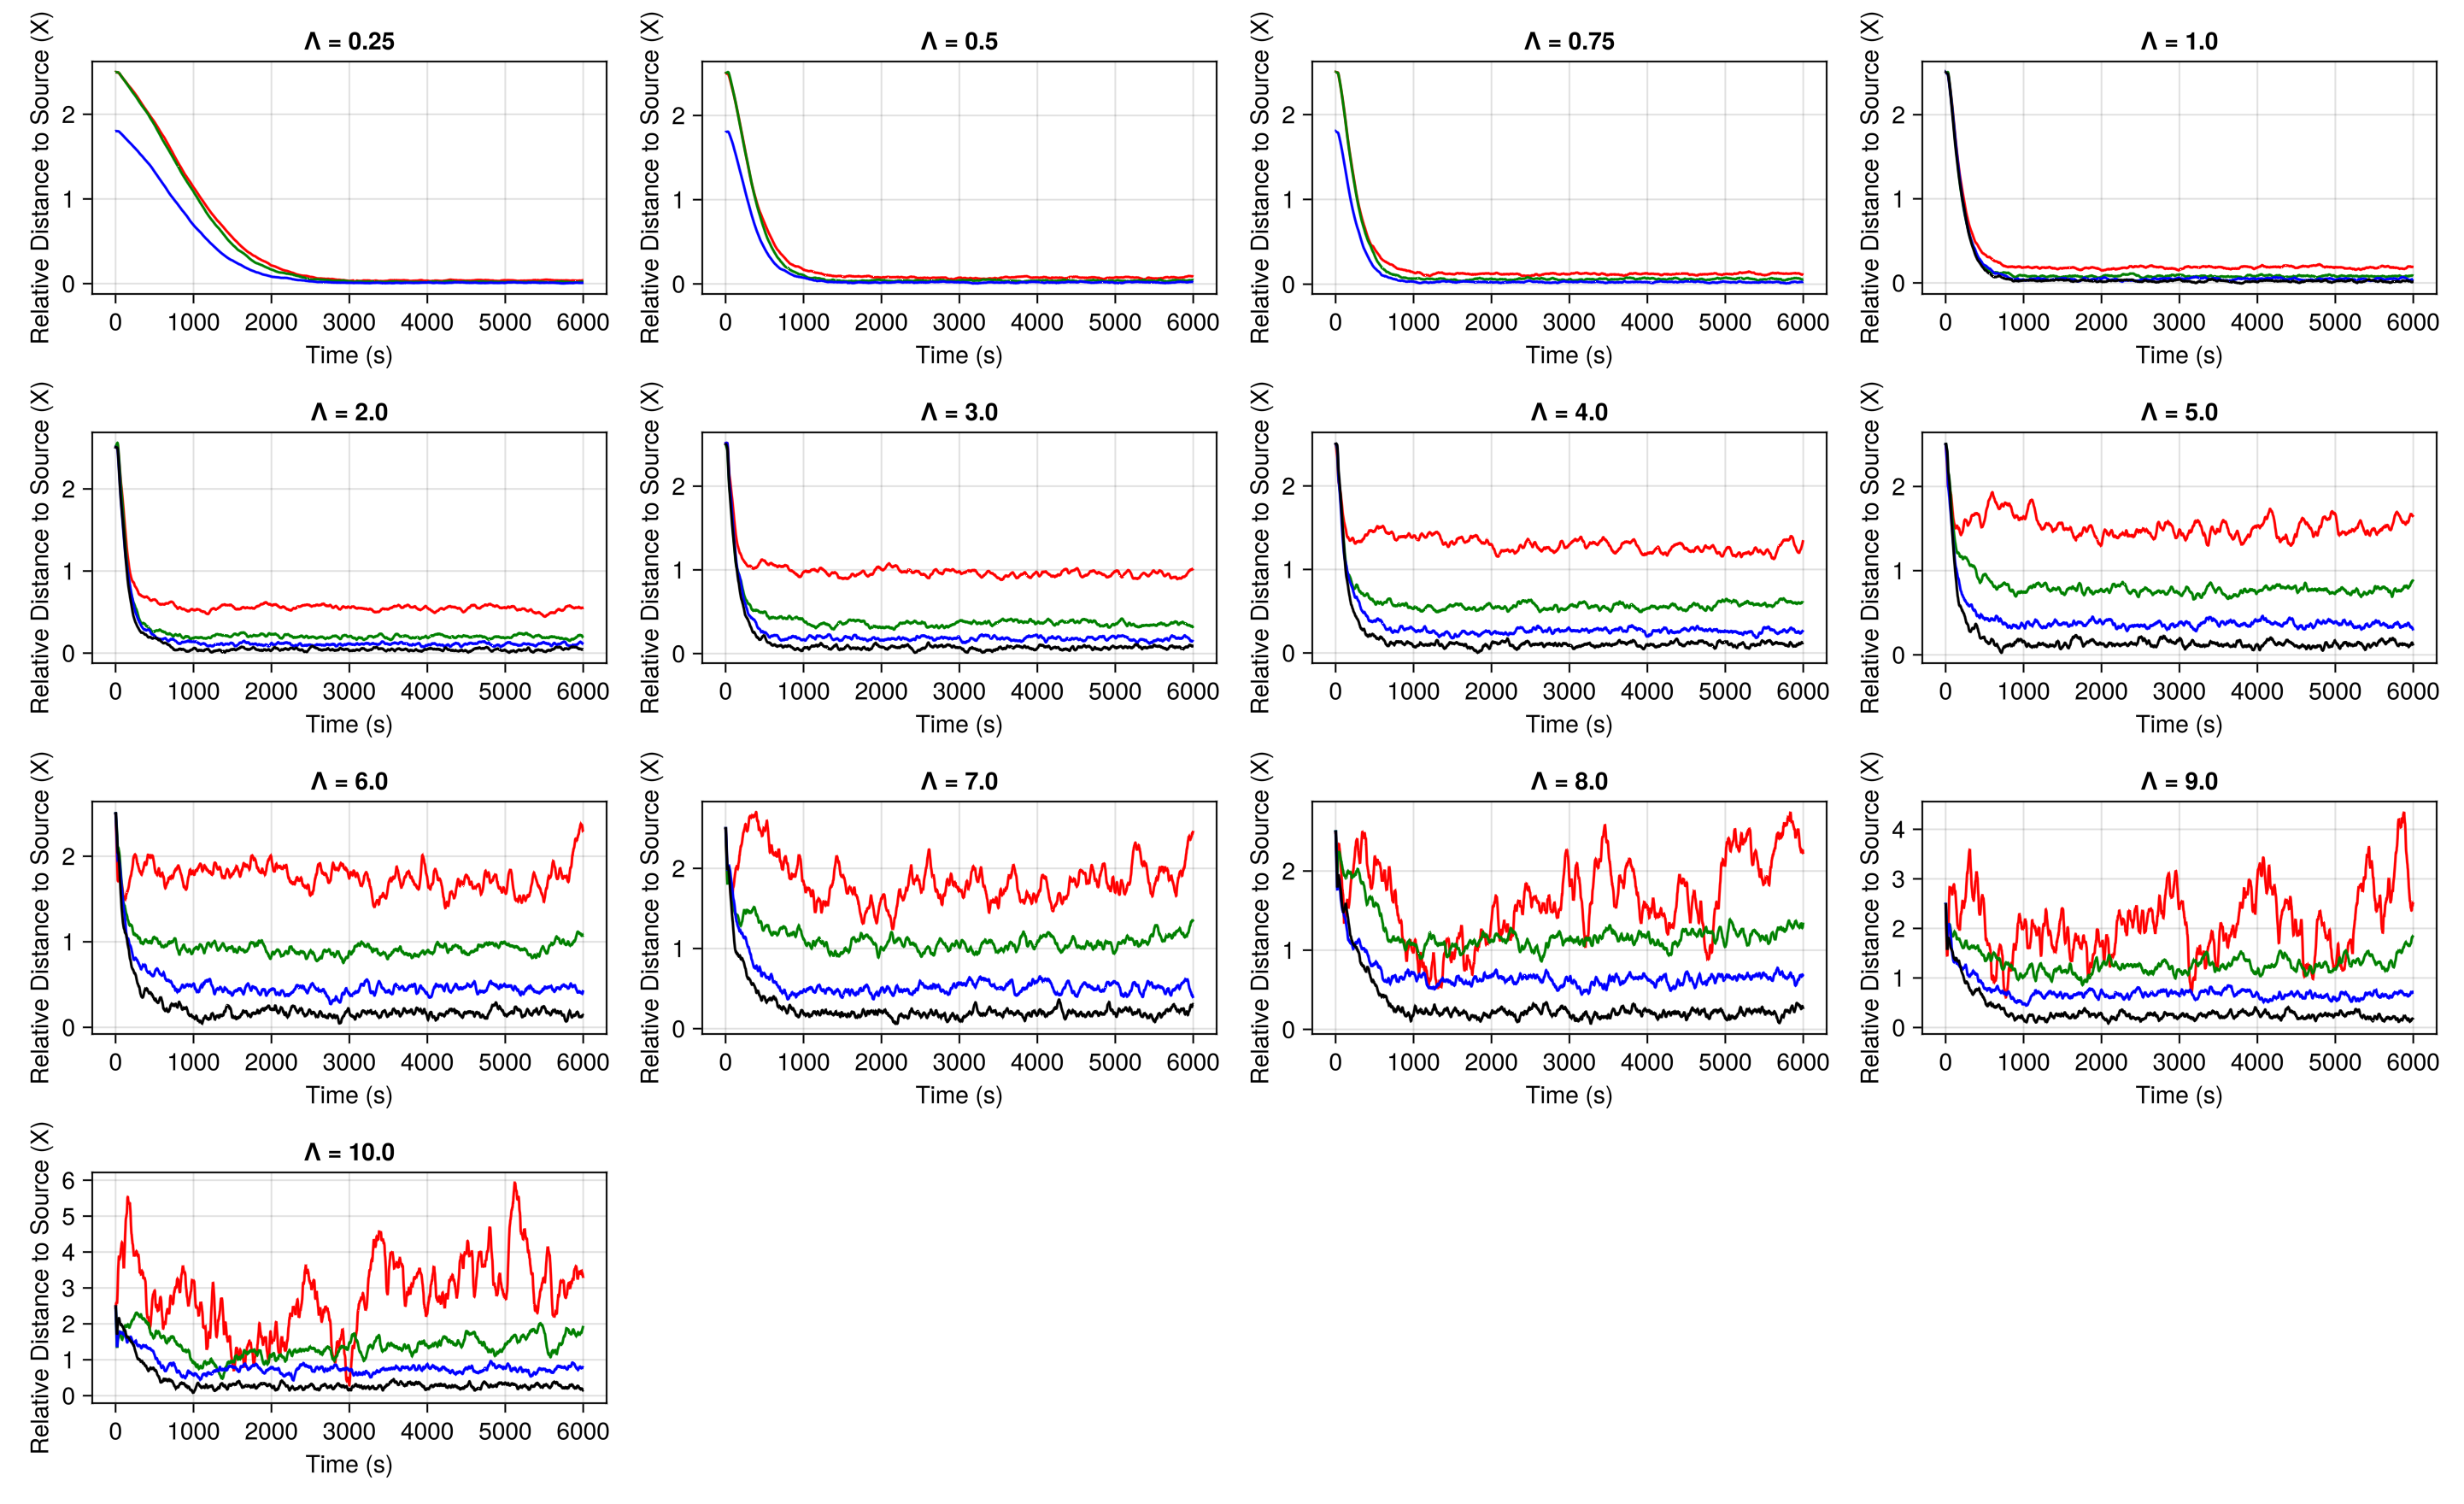

GLMakie.Screen(...)

In [338]:
lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
steps = 60000

# velocities = [5.0, 10.0, 20.0, 100.0]
velocities = [5.0, 10.0, 20.0, 100.0]
thresholds = [40, 75, 275 , 850]
colors = [:red, :green, :blue, :black]

# Create a macrofigure with a grid layout
rows = 4
cols = 4
fig3 = Figure(size=(900 * cols, 600 * rows))
fig4 = Figure(size=(900 * cols, 600 * rows))

for (idx, lambda) in enumerate(lambdas)
    row = ceil(Int, idx / cols)
    col = (idx - 1) % cols + 1
    
    # Create axis for this subplot
    ax_x = Axis(fig3[row, col], 
              xlabel="Time (s)", 
              ylabel="Relative Distance to Source (X)", # Changed label to reflect normalization
              title="Λ = $lambda")
    ax_y = Axis(fig4[row, col], 
              xlabel="Time (s)", 
              ylabel="Relative Distance to Source (Y)", # Changed label to reflect normalization
              title="Λ = $lambda")
    
    for (v_idx, v) in enumerate(velocities)

        df = combined_dfs[(v, lambda)]
        color = colors[v_idx]

        mean_x = Float64[]
        mean_y = Float64[]

        mask = (dc_delta.V .== v) .& (dc_delta.lambda .== lambda)
        
        Dc = dc_delta.Dc[mask]

        delta = dc_delta.delta[mask]

        # l = sqrt(Dc/delta)
        l = sqrt(mean(Dc) / mean(delta))

        # grouped_t = groupby(df, :step)
        grouped = groupby(df, :step)

        eq = grouped[3000:end]
        df_subset = DataFrame(eq)

        if lambda < 6.0

            bad_rows_mask = (df_subset.x .> thresholds[v_idx]) .| (df_subset.y .>  thresholds[v_idx]) .| (df_subset.x .< -thresholds[v_idx]) .| (df_subset.y .< - thresholds[v_idx])
        else
            t = (thresholds[v_idx])/2
            bad_rows_mask = (df_subset.x .> thresholds[v_idx]) .| (df_subset.y .>  thresholds[v_idx]) .| (df_subset.x .< -thresholds[v_idx]) .| (df_subset.y .< - thresholds[v_idx])
        end

        bad_agents = unique(df_subset[bad_rows_mask, :agent])

        df_clean = filter(row -> !(row.agent in bad_agents), df)

        if isempty(df_clean)
            @warn "No data for v=$v, lambda=$lambda. Skipping."
            continue
        end

        grouped_t = groupby(df_clean, :step)
        
        if isempty(grouped_t)
             @warn "No steps found in filtered data."
             continue
        end


        for i in 1:length(grouped_t)
            data_1 = grouped_t[i]
            x = data_1.x ./l
            y = data_1.y ./l

            push!(mean_x, mean(x))
            push!(mean_y, mean(y))
        end
        
        lines!(ax_x, 1:length(grouped_t), mean_x, color = color, label = "$v")
        lines!(ax_y, 1:length(grouped_t), mean_y, color = color, label = "$v")

        if idx == 1 & v_idx == 4
            Legend(fig3[:,5], ax_x, "Velocity")
            Legend(fig4[:,5], ax_y, "Velocity")
        end
    end
end

display(fig3)

In [337]:
save("Plots/Fixed_source_model/v_collapse_trapped_x.png", fig3)
save("Plots/Fixed_source_model/v_collapse_trapped_y.png", fig4)


# OU mean

In [ ]:
function simulate_OU(k, D, dt, T, r0)
    nsteps = Int(T/dt)
    r = zeros(nsteps)
    r[1] = r0

    for i in 2:nsteps
        ξ = randn()
        r[i] = r[i-1] - k * r[i-1] * dt + sqrt(2 * D * dt) * ξ

        # optional: avoid negative distance
        if r[i] < 0
            r[i] = 0.0
        end
    end

    return r
end

In [ ]:
k = (metrics_combined.k_x + metrics_combined.k_y) / 2
D = ((metrics_combined.sigma_x + metrics_combined.sigma_y) / 2) * sqrt(2 * k)
dt = 0.01
T = 600
l = 
r0 = l * 2.5
agents = 1000
steps = 60000
distance_vec = zeros(steps, agents)
for agent in 1:agents
    distance_vec[agent, :] = simulate_OU(k, D, dt, T, r0)
end

# Intent keller


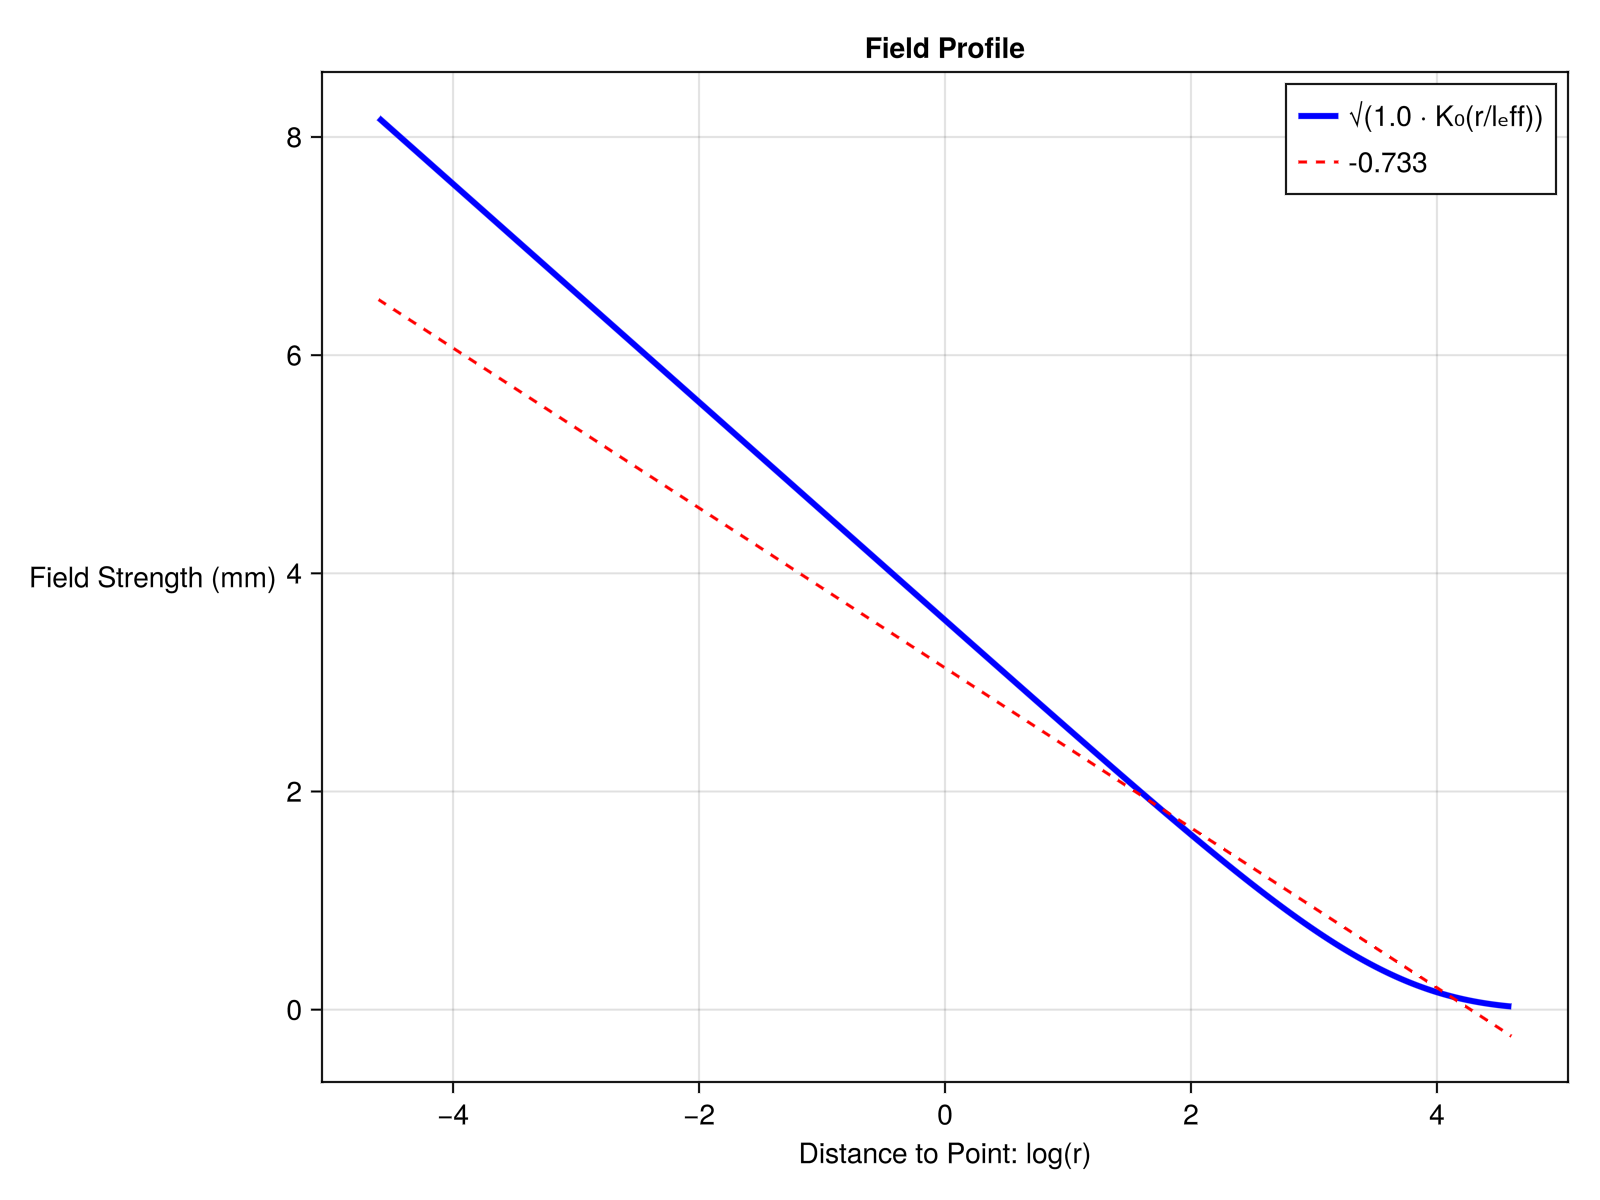

In [273]:
# --- 1. CONFIGURATION ---
mm_factor = 1.0
Dc = 10.0
delta = 0.01
ll = sqrt(Dc/delta)        # Effective length scale (l_eff)
r_max = 100.0         # Maximum distance to plot (e.g., 5 * ll)

# Generate distance vector (x-axis)
# Start at 0.01 to avoid the singularity at r=0 (K0(0) -> Inf)
r = LinRange(0.01, r_max, 500) 

# --- 2. CALCULATION ---
# Calculate m = 1.0 * K0(r / ll)
# besselk(0, x) is the modified Bessel function of the second kind, order 0
m_vals = mm_factor .* besselk.(0, r ./ ll)

# Calculate the square root
# Ensure we don't take sqrt of negative numbers (K0 is positive for r>0)
sqrt_m_vals = sqrt.(m_vals)

# --- 3. PLOTTING ---
fig = Figure(size = (800, 600), fontsize = 14)
ax = Axis(fig[1, 1], 
          title = "Field Profile",
          xlabel = "Distance to Point: log(r)",
          ylabel = "Field Strength (mm)",
          ylabelrotation = 0)

# Plot the line
lines!(ax, log.(r), m_vals, 
       color = :blue, 
       linewidth = 3, 
       label = "√(1.0 · K₀(r/lₑff))")

slope_x, intercept_x = linear_fit(log.(r), m_vals)
fitted_line_x = [intercept_x + slope_x * t for t in log.(r)]
lines!(ax, log.(r), fitted_line_x, label = "$(round(slope_x, digits = 4))", color = :red, linestyle = :dash)



# Add legend
axislegend(ax, position = :rt)

# Display the figure
fig

In [274]:
save("Plots/Fixed_source_model/mm_logr.png", fig)

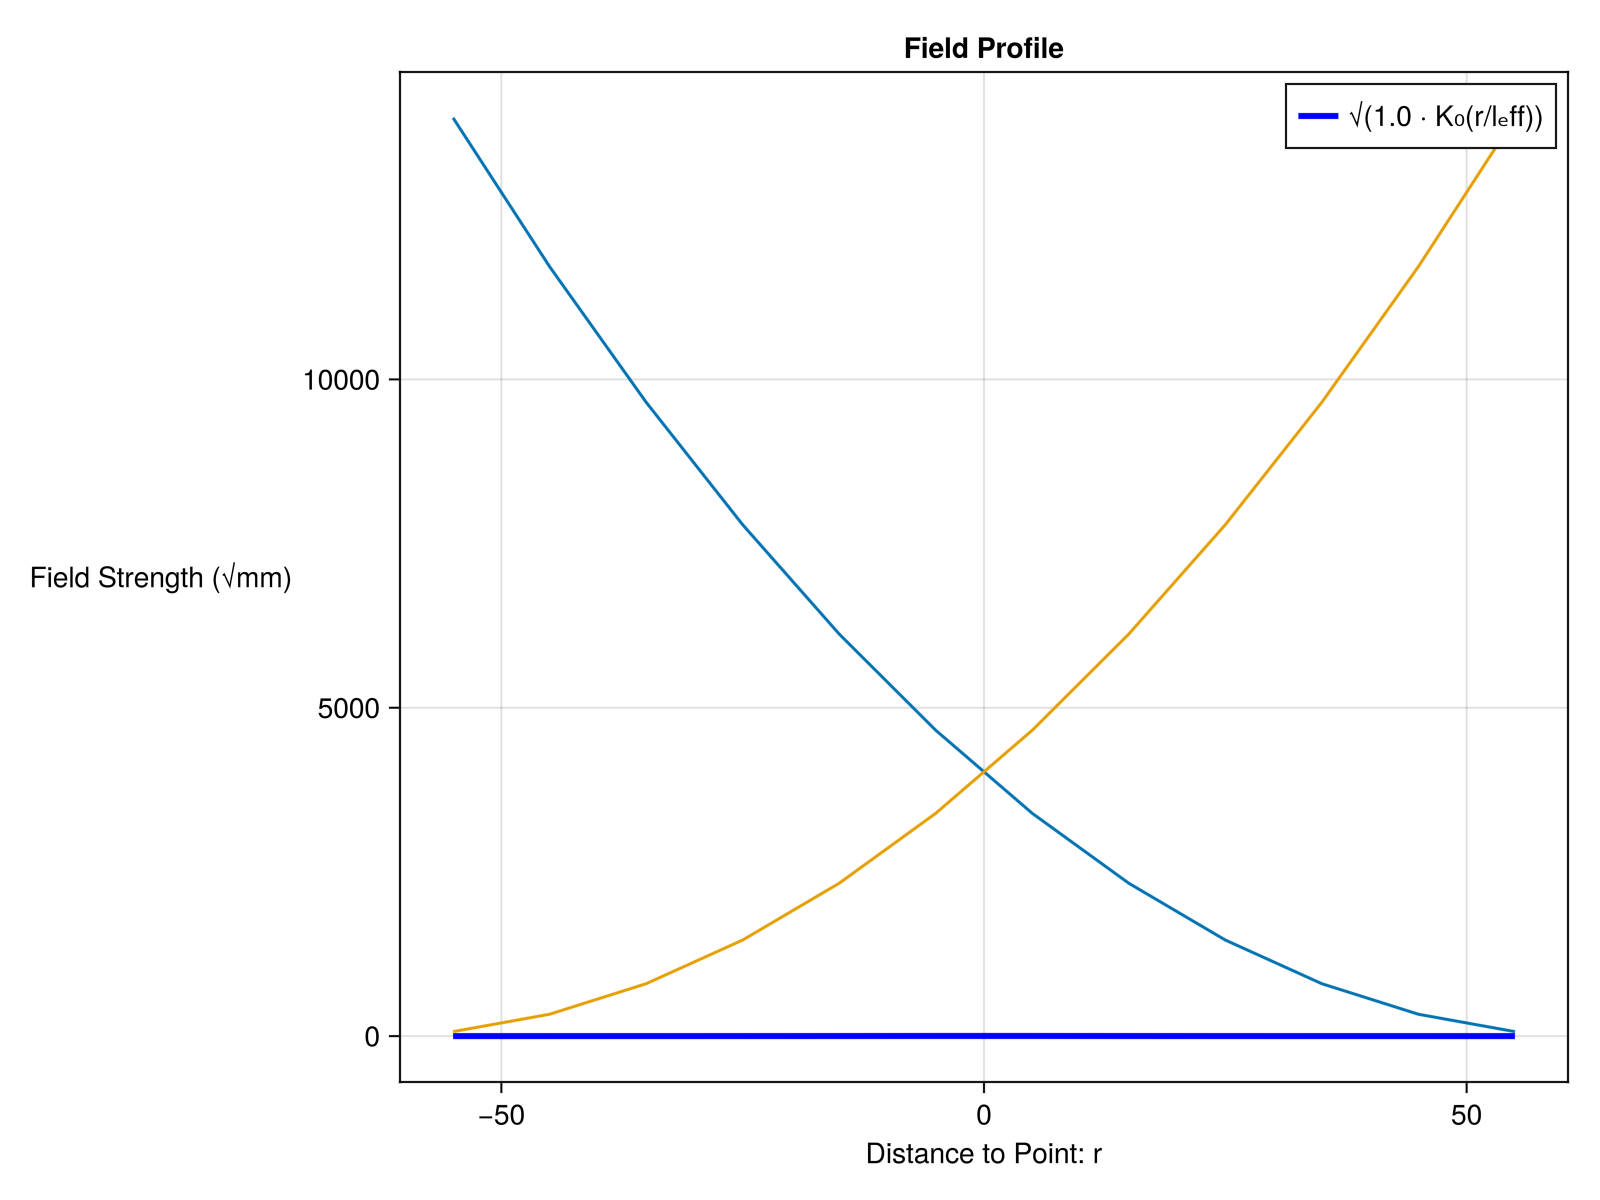

In [389]:
# --- 1. CONFIGURATION ---
mm_factor = 1.0
Dc = 10.0
delta = 0.01
ll = sqrt(Dc/delta)        # Effective length scale (l_eff)
r_max = 55        # Maximum distance to plot (e.g., 5 * ll)

# Generate distance vector (x-axis)
# Start at 0.01 to avoid the singularity at r=0 (K0(0) -> Inf)
# r = LinRange(-55, r_max, 10) 
x = -55:10:55

# --- 2. CALCULATION ---
# Calculate m = 1.0 * K0(r / ll)
# besselk(0, x) is the modified Bessel function of the second kind, order 0
m_vals = mm_factor .* besselk.(0, abs.(x) ./ ll)

# Calculate the square root
# Ensure we don't take sqrt of negative numbers (K0 is positive for r>0)
sqrt_m_vals = sqrt.(m_vals)

# --- 3. PLOTTING ---
fig = Figure(size = (800, 600), fontsize = 14)
ax = Axis(fig[1, 1], 
          title = "Field Profile",
          xlabel = "Distance to Point: r",
          ylabel = "Field Strength (√mm)",
          ylabelrotation = 0)

# Plot the line
lines!(ax, x, m_vals, 
       color = :blue, 
       linewidth = 3, 
       label = "√(1.0 · K₀(r/lₑff))")
# h = 2
# y = h .* (1 .-(x.^2 ./ll .^2*2))

# lines!(ax, x, y)

a=2*ll
y1= ((x).-a).^2 
y2= ((x).+a).^2 
lines!(ax, x, y1)
lines!(ax, x, y2)


# slope_x, intercept_x = linear_fit(x, sqrt_m_vals)
# fitted_line_x = [intercept_x + slope_x * t for t in r]
# lines!(ax, x, fitted_line_x, label = "$(round(slope_x, digits = 4))", color = :red, linestyle = :dash)
# ylims!(ax, 0, 2)


# Add legend
axislegend(ax, position = :rt)

# Display the figure
fig

In [277]:
save("Plots/Fixed_source_model/sqrt(mm)_r.png", fig)

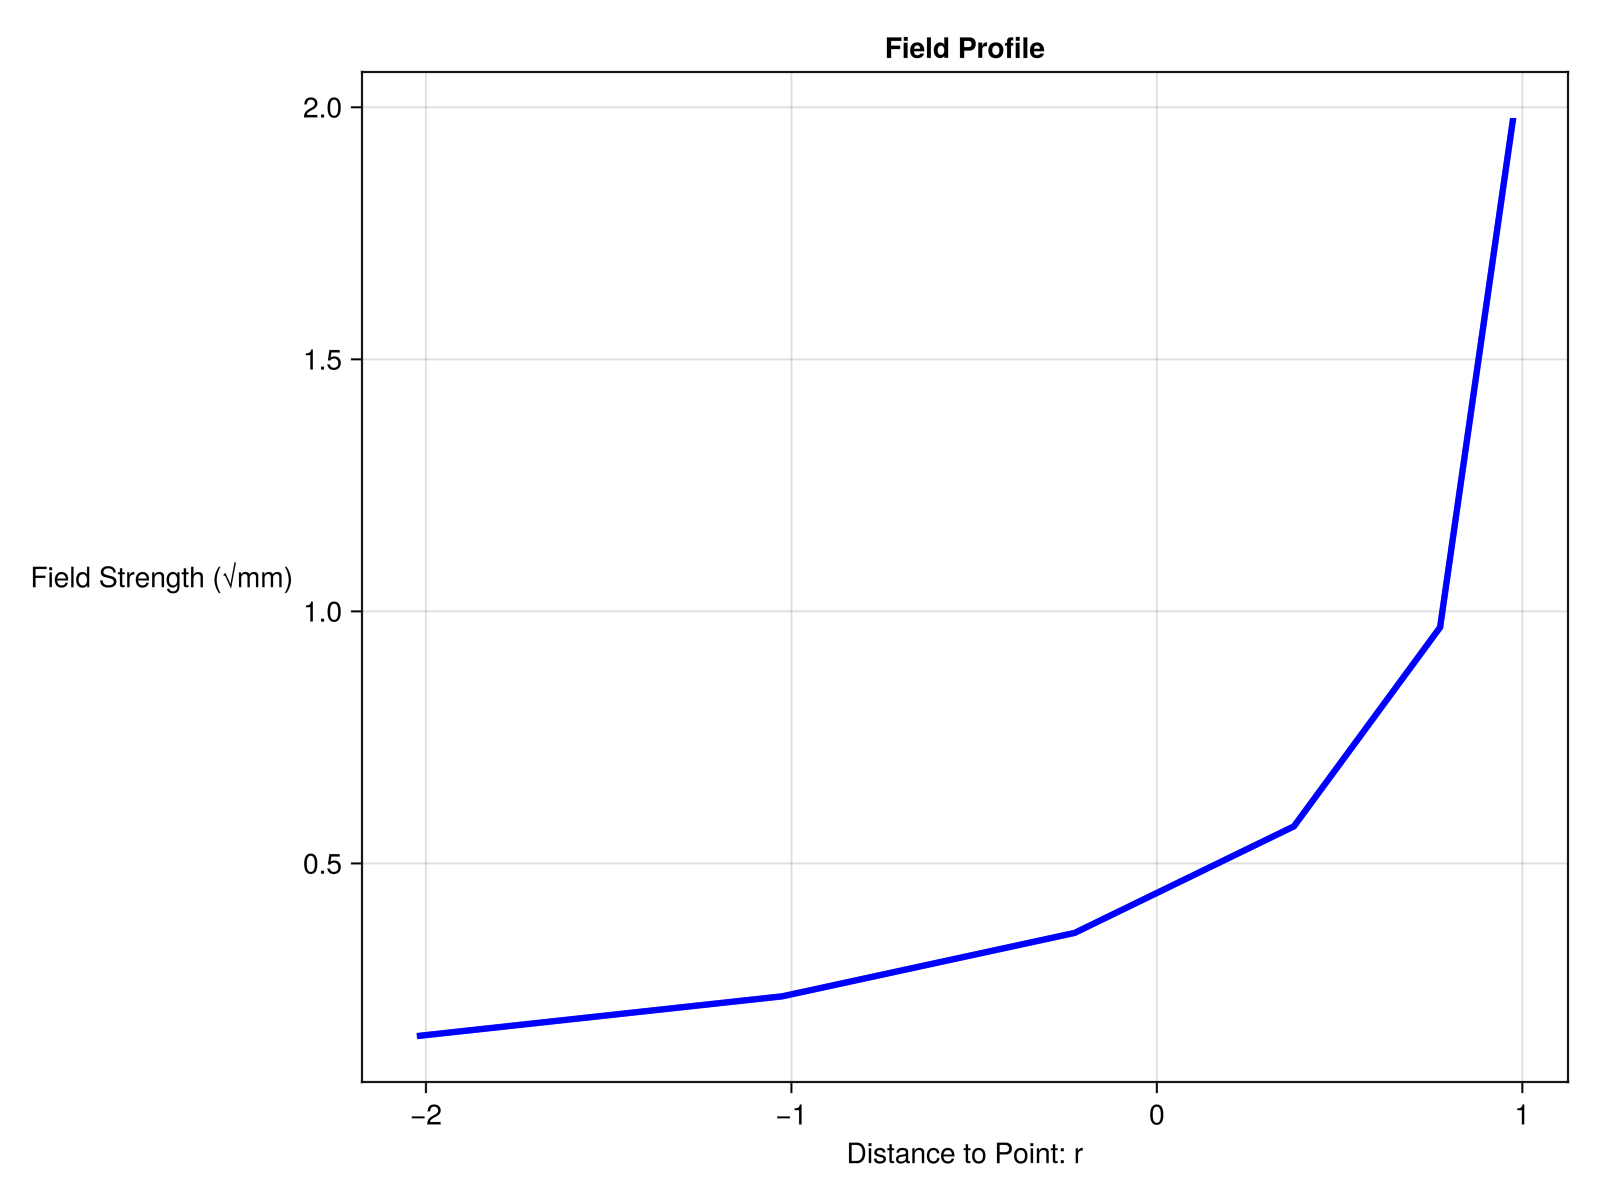

In [376]:
# --- 1. CONFIGURATION ---
mm_factor = 1.0
Dc = 10.0
delta = 0.01
ll = sqrt(Dc/delta)        # Effective length scale (l_eff)
r_max = 55        # Maximum distance to plot (e.g., 5 * ll)

# Generate distance vector (x-axis)
# Start at 0.01 to avoid the singularity at r=0 (K0(0) -> Inf)
# r = LinRange(-55, r_max, 10) 
x = -55:10:55

# --- 2. CALCULATION ---
# Calculate m = 1.0 * K0(r / ll)
# besselk(0, x) is the modified Bessel function of the second kind, order 0
m_vals = mm_factor .* besselk.(0, abs.(x) ./ ll)

# Calculate the square root
# Ensure we don't take sqrt of negative numbers (K0 is positive for r>0)
sqrt_m_vals = sqrt.(m_vals)

# --- 3. PLOTTING ---
fig = Figure(size = (800, 600), fontsize = 14)
ax = Axis(fig[1, 1], 
          title = "Field Profile",
          xlabel = "Distance to Point: r",
          ylabel = "Field Strength (√mm)",
          ylabelrotation = 0)

# Plot the line
lines!(ax, 1 .- ((x.^2)./ll.^2), m_vals, 
       color = :blue, 
       linewidth = 3, 
       label = "√(1.0 · K₀(r/lₑff))")

# slope_x, intercept_x = linear_fit(x, sqrt_m_vals)
# fitted_line_x = [intercept_x + slope_x * t for t in r]
# lines!(ax, x, fitted_line_x, label = "$(round(slope_x, digits = 4))", color = :red, linestyle = :dash)



# Add legend
# axislegend(ax, position = :rt)

# Display the figure
fig

In [374]:
m_vals[Int(length(m_vals)/2)]

InexactError: InexactError: Int64(11.5)

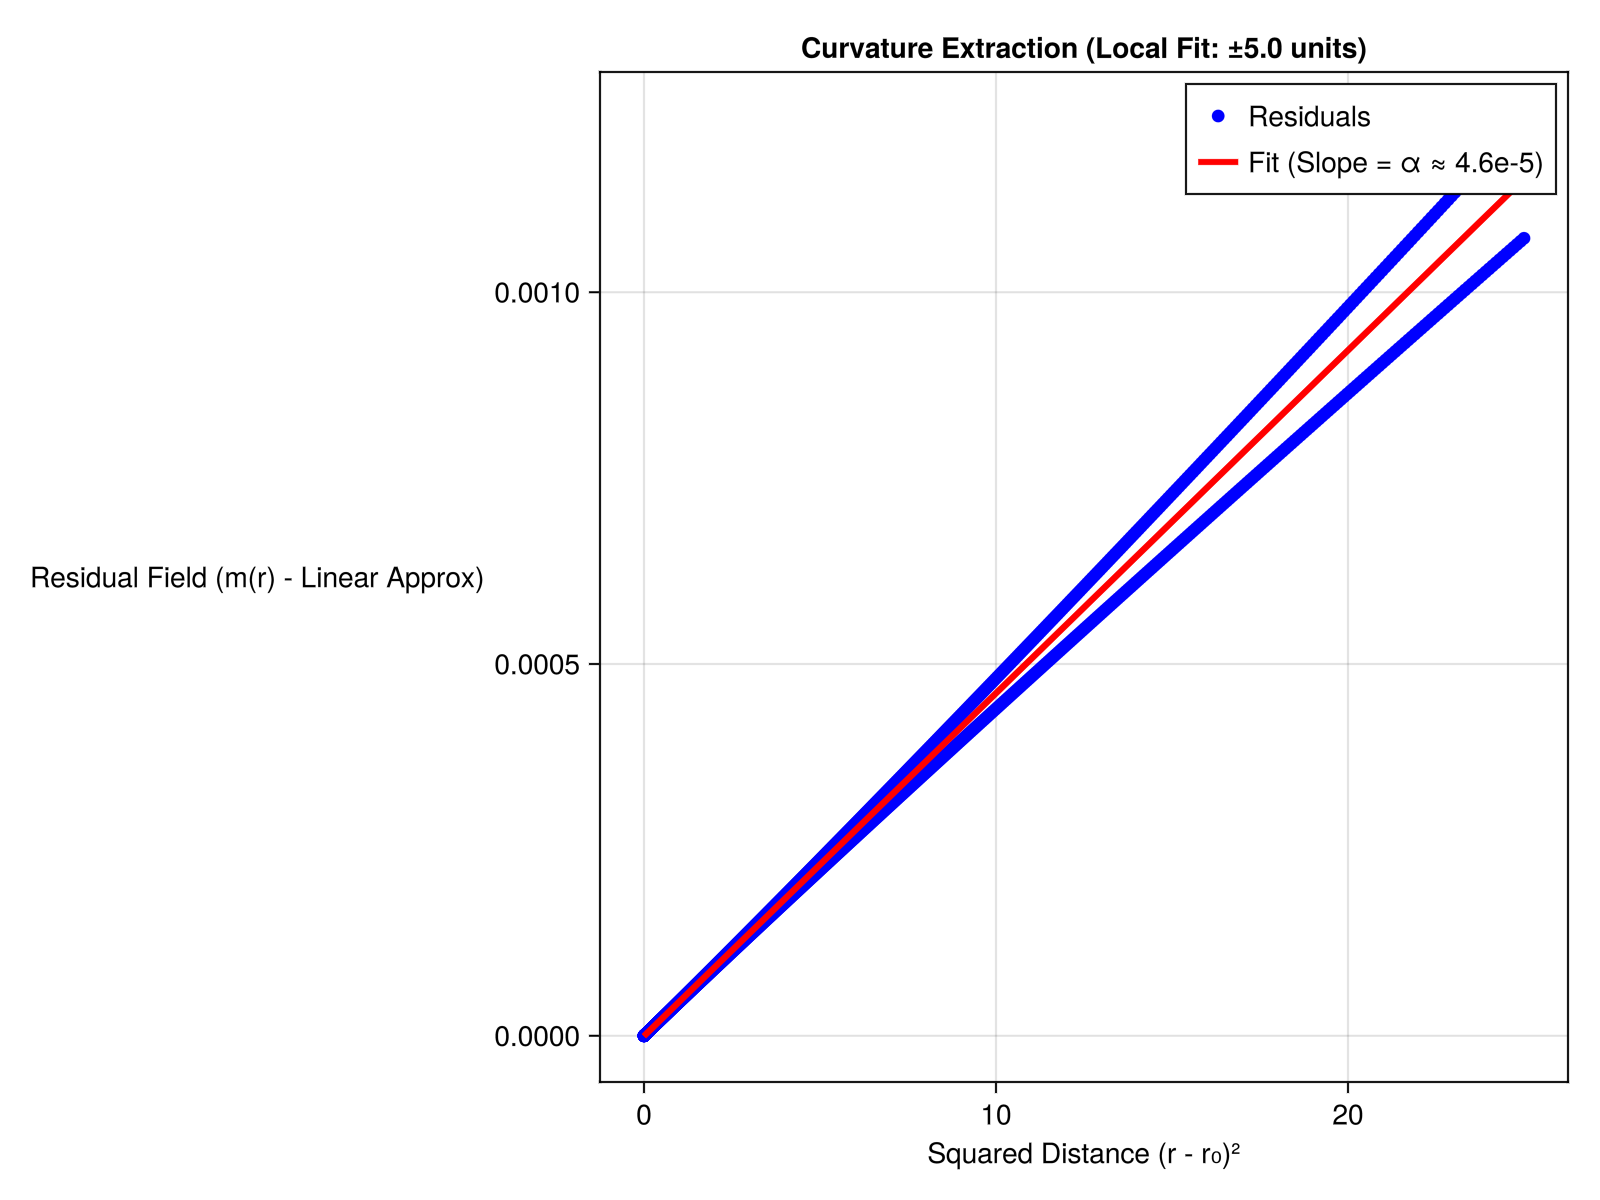

In [344]:
# --- 1. CONFIGURATION ---
Dc = 10.0
delta = 0.01
ll = sqrt(Dc/delta)        # ll ≈ 31.62
r0 = 2.5 * ll              # r0 ≈ 79.06

# --- CRITICAL: Define a TINY window ---
# We want the max (r - r0) to be small, e.g., 5.0
# This makes (r-r0)^2 max at 25.0
window_radius = 5.0        

r_min = (r0 - window_radius) > 0.01 ? (r0 - window_radius) : 0.01
r_max = r0 + window_radius
r = LinRange(r_min, r_max, 1000) 

# --- 2. CALCULATION ---
m_vals = 1.0 .* besselk.(0, r ./ ll)

# --- 3. LOCAL LINEARIZATION ---
m0 = besselk(0, r0 / ll)
m0_prime = - (1.0 / ll) * besselk(1, r0 / ll)

linear_approx = m0 .+ m0_prime .* (r .- r0)
residual = m_vals .- linear_approx
dist_sq = (r .- r0).^2

# --- 4. FITTING ---
x_fit = dist_sq
y_fit = residual

n = length(x_fit)
sum_x = sum(x_fit)
sum_y = sum(y_fit)
sum_xy = sum(x_fit .* y_fit)
sum_x2 = sum(x_fit .^ 2)

denominator = n * sum_x2 - sum_x^2
slope = (n * sum_xy - sum_x * sum_y) / denominator
intercept = (sum_y - slope * sum_x) / n

alpha_extracted = slope

# --- 5. PLOTTING ---
fig = Figure(size = (800, 600), fontsize = 14)
ax = Axis(fig[1, 1], 
          title = "Curvature Extraction (Local Fit: ±5.0 units)",
          xlabel = "Squared Distance (r - r₀)²",
          ylabel = "Residual Field (m(r) - Linear Approx)",
          xlabelrotation = 0,
          ylabelrotation = 0)

scatter!(ax, x_fit, y_fit, 
         color = :blue, 
         label = "Residuals",
         marker = :circle)

fitted_line = [intercept + slope * t for t in x_fit]
lines!(ax, x_fit, fitted_line, 
       color = :red, 
       linewidth = 3, 
       label = "Fit (Slope = α ≈ $(round(alpha_extracted, digits=6)))")

# annotate!(ax, 0.1 * max(x_fit), 0.9 * max(y_fit), 
#           Text("α ≈ $(round(alpha_extracted, digits=6))", 14, :red))

axislegend(ax, position = :rt)

fig